# Russell 2000 – Marktbreite als Frühindikator für ein Ampelsystem

### Eine Hypothesenanalyse auf Basis der prozentualen Marktbreite

Diese Analyse untersucht, ob die Marktbreite des Russell 2000 – der Anteil der
Indexmitglieder, die über ihrem eigenen gleitenden Durchschnitt (SMA20/50/200)
notieren – eigenständige Aussagekraft für die Rendite- und Risikoentwicklung
des Gesamtindex besitzt. Die Marktbreite misst, wie viele einzelne
Indexmitglieder eine Trendbewegung tatsächlich mittragen – eine breit
getragene Rally gilt als robuster als eine von wenigen Werten getriebene.
Ziel ist die Identifikation robuster, statistisch abgesicherter
Frühindikatoren als Bausteine für ein indikatorbasiertes Ampelsystem, das
die aktuelle Marktphase hinsichtlich ihres Rendite- und Risikoprofils
einordnet.

Neun Hypothesen werden untersucht (B1–B9), gefolgt von einer breitenbasierten
Ampel-Systematik und einer Was-wäre-wenn-Analyse:

**Aufbau:**

1. Datenbezug und Aufbereitung
2. Datenbereinigung und Plausibilisierung
3. Methodik und Hypothesenübersicht
4. Hypothesenanalyse (B1–B9)
5. Einordnung und Handlungsempfehlungen
6. Ampel-Systematik auf Basis der Marktbreite
7. Was-wäre-wenn-Analyse
8. Export der Ergebnisse
9. Zusammenfassung


## 1. Datenbezug und Aufbereitung


### 1.1 Verwendete Bibliotheken


In [1]:
# Numerik, Tabellenverarbeitung und Pfadhandling
import numpy as np
import pandas as pd
from pathlib import Path
from itertools import combinations

# Statistische Tests (Welch-t-Test, Mann-Whitney-U, Kruskal-Wallis) für die
# Gruppen- bzw. Quartilsvergleiche in Abschnitt 3
from scipy import stats
import matplotlib.pyplot as plt

# Einheitliche Farbpalette für sämtliche Diagramme des Notebooks
COLOR_PRICE = "#0b0b0b"
COLOR_A     = "#2a78d6"
COLOR_B     = "#eb6834"
COLOR_GOOD  = "#0ca30c"
COLOR_WARN  = "#e0a72c"
COLOR_BAD   = "#d03b3b"
COLOR_GRID  = "#e1e0d9"
COLOR_MUTED = "#898781"
# Vier sequenzielle Farben für die Quartils-Diagramme (B3, dunkler = höhere Breite)
COLOR_QUARTILE = ["#f2c6b4", "#eb6834", "#2a78d6", "#123a63"]

plt.rcParams.update({
    "figure.figsize": (11, 4.5),
    "axes.grid": True,
    "grid.color": COLOR_GRID,
    "grid.linewidth": 0.8,
    "axes.edgecolor": COLOR_MUTED,
    "axes.labelcolor": "#0b0b0b",
    "text.color": "#0b0b0b",
    "xtick.color": COLOR_MUTED,
    "ytick.color": COLOR_MUTED,
    "font.size": 10,
})

pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
print("Bibliotheken geladen.")


Bibliotheken geladen.


### 1.2 Konfiguration


In [2]:
# Zu untersuchender Index
INDEX_NAME = "Russell 2000"

# Fensterlängen der Marktbreite-Kennzahl (Anteil Mitglieder über eigenem SMA)
BREADTH_WINDOWS = [20, 50, 200]

# Rohdaten-Dateien je Fenster (TradingView-Export: Anteil Russell-2000-Mitglieder
# über ihrem eigenen SMA20/50/200, täglicher Schlusswert in Prozent)
BREADTH_FILES = {
    20:  Path("Rohdaten/Russell 2000 20 SMA 20131014 - 20260804.csv"),
    50:  Path("Rohdaten/Russell 2000 50 SMA 20131014 - 20260804.csv"),
    200: Path("Rohdaten/Russell 2000 200 SMA 20131014 - 20260804.csv"),
}

# Kursdaten inkl. bereits berechneter Wochenbasis-SMA und Vorwärts-Zielgrößen
# (fwd_return/fwd_mdd) für die Horizonte 30/60/90 Handelstage.
PRICE_FILE = Path("../data/Russell_2000_clean_with_sma.csv")

# Analysezeitraum: Die Kursdaten liegen bereits ab 2007 vor, die
# Marktbreite-Rohdaten für den Russell 2000 jedoch erst ab 2013-10-14
# (alle drei Fenster gleichermaßen, siehe Abschnitt 2.1). Die Finanzkrise
# 2008/2009 ist damit in dieser Marktbreite-Analyse nicht abgedeckt. Der
# untere Grenzwert unten bleibt bei 2007-01-01, da die anschließende
# Zusammenführung der Breiten- mit den Kursdaten per innerem Verbund
# (Abschnitt 2.3) den tatsächlichen Analysezeitraum ohnehin automatisch auf
# die Schnittmenge ab 2013-10-14 begrenzt.
START_DATE_ANALYSE = "2007-01-01"

# Feste (absolute) Quartilsgrenzen der Marktbreite in Prozent - konsistent mit
# den in B4/B5/B6/B7 verwendeten Schwellen von 25/50/75 %.
QUARTIL_GRENZEN = [0, 25, 50, 75, 100]
QUARTIL_LABELS = ["Q1 (0-25%)", "Q2 (25-50%)", "Q3 (50-75%)", "Q4 (75-100%)"]

# Prognosehorizonte in Handelstagen (identisch zu den bereits vorliegenden
# fwd_return_*/fwd_mdd_*-Spalten der Kursdaten)
HORIZONS = [30, 60, 90]

# Zielordner für den Export der Ergebnistabellen (Abschnitt 8)
EXPORT_DIR = Path("Hypothesenanalysen")
EXPORT_DIR.mkdir(exist_ok=True)

print(f"Untersuchter Index: {INDEX_NAME}")
print(f"Marktbreite-Fenster: {BREADTH_WINDOWS}")
print(f"Analysezeitraum ab: {START_DATE_ANALYSE}")
print(f"Ergebnisordner: {EXPORT_DIR.resolve()}")


Untersuchter Index: Russell 2000
Marktbreite-Fenster: [20, 50, 200]
Analysezeitraum ab: 2007-01-01
Ergebnisordner: C:\Users\ramos\OneDrive\Privat\Data Science Institute\Abschlussprojekt - final\Breitenindikatoren\Hypothesenanalysen


### 1.3 Marktbreite-Datenbezug


In [3]:
def lade_breite(pfad: Path, fenster: int) -> pd.Series:
    '''Lädt eine TradingView-Marktbreite-Exportdatei und liefert den
    täglichen Schlusswert (Anteil Mitglieder über eigenem SMA, in Prozent)
    als benannte Series. Die Spalten open/high/low sowie die vier unbenannten
    EMA-Glättungsspalten werden nicht verwendet (siehe Abschnitt 2.1).'''
    rohdaten = pd.read_csv(pfad, parse_dates=["time"])
    reihe = rohdaten.set_index("time")["close"]
    reihe.index.name = "Date"
    reihe.name = f"breite_sma{fenster}"
    return reihe


breite_rohdaten = {w: lade_breite(pfad, w) for w, pfad in BREADTH_FILES.items()}
for w, reihe in breite_rohdaten.items():
    print(f"SMA{w}: {len(reihe):,} Zeilen, Zeitraum {reihe.index.min().date()} bis "
          f"{reihe.index.max().date()}, Wertebereich {reihe.min():.2f} bis {reihe.max():.2f}")


SMA20: 3,221 Zeilen, Zeitraum 2013-10-14 bis 2026-08-04, Wertebereich 1.46 bis 96.23
SMA50: 3,221 Zeilen, Zeitraum 2013-10-14 bis 2026-08-04, Wertebereich 1.62 bis 95.05
SMA200: 3,221 Zeilen, Zeitraum 2013-10-14 bis 2026-08-04, Wertebereich 5.72 bis 93.06


### 1.4 Kursdatenbezug


In [4]:
def lade_kursdaten(pfad: Path) -> pd.DataFrame:
    '''Lädt die bereits bereinigten Kurs- und SMA-Daten des Index
    (Date, Close, wöchentliche SMA sowie Vorwärts-Zielgrößen für
    30/60/90 Handelstage).'''
    df = pd.read_csv(pfad, parse_dates=["Date"], index_col="Date")
    return df


preis_df = lade_kursdaten(PRICE_FILE)
print(f"Kursdaten: {len(preis_df):,} Zeilen, Zeitraum {preis_df.index.min().date()} bis "
      f"{preis_df.index.max().date()}")
preis_df[["Close"] + [f"fwd_return_{h}d" for h in HORIZONS]].tail()


Kursdaten: 4,925 Zeilen, Zeitraum 2007-01-03 bis 2026-07-31


,Close,fwd_return_30d,fwd_return_60d,fwd_return_90d
Date,,,,
2026-07-27,"2,948.0400",NaN,NaN,NaN
2026-07-28,"2,953.8000",NaN,NaN,NaN
2026-07-29,"2,906.3101",NaN,NaN,NaN
2026-07-30,"2,946.1001",NaN,NaN,NaN
2026-07-31,"2,931.3401",NaN,NaN,NaN


## 2. Datenbereinigung und Plausibilisierung


### 2.1 Datenqualitätsprüfung


In [5]:
def breite_qualität_report(reihe: pd.Series) -> dict:
    gap_days = reihe.index.to_series().diff().dt.days
    return {
        "Anzahl Zeilen": len(reihe),
        "Duplizierte Datums-Indizes": int(reihe.index.duplicated().sum()),
        "Fehlende Werte": int(reihe.isna().sum()),
        "Werte außerhalb 0-100": int(((reihe < 0) | (reihe > 100)).sum()),
        "Größte Datenlücke (Kalendertage)": float(gap_days.max()) if len(gap_days.dropna()) else np.nan,
        "Anteil Lücken > 30 Kalendertage": float((gap_days > 30).mean()),
    }


print("--- Datenqualitätsbericht je Marktbreite-Fenster (Rohdaten) ---")
for w, reihe in breite_rohdaten.items():
    print(f"\nSMA{w}:")
    for k, v in breite_qualität_report(reihe).items():
        print(f"  {k:.<48s} {v}")


--- Datenqualitätsbericht je Marktbreite-Fenster (Rohdaten) ---

SMA20:
  Anzahl Zeilen................................... 3221
  Duplizierte Datums-Indizes...................... 0
  Fehlende Werte.................................. 0
  Werte außerhalb 0-100........................... 0
  Größte Datenlücke (Kalendertage)................ 4.0
  Anteil Lücken > 30 Kalendertage................. 0.0

SMA50:
  Anzahl Zeilen................................... 3221
  Duplizierte Datums-Indizes...................... 0
  Fehlende Werte.................................. 0
  Werte außerhalb 0-100........................... 0
  Größte Datenlücke (Kalendertage)................ 4.0
  Anteil Lücken > 30 Kalendertage................. 0.0

SMA200:
  Anzahl Zeilen................................... 3221
  Duplizierte Datums-Indizes...................... 0
  Fehlende Werte.................................. 0
  Werte außerhalb 0-100........................... 0
  Größte Datenlücke (Kalendertage)............

**Befund:** Alle drei Marktbreite-Fenster (SMA20/50/200) des Russell 2000
liegen einheitlich erst ab **2013-10-14** vor und sind ab diesem Datum
durchgehend täglich befüllt - anders als beim Kursdatensatz, der bereits ab
2007 beginnt. Ein Vorlauf mit dünnerer Befüllung wie bei anderen Indizes
existiert hier nicht; die Historie setzt schlicht erst 2013 ein. In der
Konsequenz ist die **Finanzkrise 2008/2009 in dieser Marktbreite-Analyse des
Russell 2000 nicht abgedeckt** - der tatsächlich auswertbare Zeitraum
beginnt erst gut vier Jahre danach. `START_DATE_ANALYSE` (2007-01-01) wird
unten unverändert belassen; die anschließende Zusammenführung mit den
Kursdaten per innerem Verbund (Abschnitt 2.3) begrenzt den tatsächlichen
Analysezeitraum automatisch auf die Schnittmenge ab 2013-10-14.


### 2.2 Bereinigungsschritte


In [6]:
def bereinige_breite(reihe: pd.Series) -> pd.Series:
    bereinigt = reihe[~reihe.index.duplicated(keep="first")].sort_index()
    bereinigt = bereinigt.loc[bereinigt.index >= START_DATE_ANALYSE]
    return bereinigt


breite_bereinigt = {w: bereinige_breite(r) for w, r in breite_rohdaten.items()}

# Zusammenführung der drei Marktbreite-Fenster zu einer gemeinsamen Tabelle
breite_df = pd.concat(breite_bereinigt.values(), axis=1)
print(f"Marktbreite (alle Fenster gemeinsam) nach Bereinigung: {len(breite_df):,} Zeilen "
      f"({breite_df.index.min().date()} bis {breite_df.index.max().date()})")

n_unvollständig = int(breite_df.isna().any(axis=1).sum())
print(f"Handelstage mit mindestens einem fehlenden Breitenwert: {n_unvollständig} "
      f"({n_unvollständig / len(breite_df):.1%})")
breite_df = breite_df.dropna()


Marktbreite (alle Fenster gemeinsam) nach Bereinigung: 3,221 Zeilen (2013-10-14 bis 2026-08-04)
Handelstage mit mindestens einem fehlenden Breitenwert: 0 (0.0%)


### 2.3 Zusammenführung mit den Kursdaten


In [7]:
# Innerer Verbund über den Handelskalender: TradingView (Marktbreite) und
# Yahoo Finance (Kurs) weichen an einzelnen Tagen leicht voneinander ab: Nur
# Handelstage, die in beiden Quellen vorhanden sind, gehen in die Analyse ein.
df = breite_df.join(preis_df, how="inner")
df = df.loc[df.index >= START_DATE_ANALYSE].copy()

anteil_verworfen_breite = 1 - len(df) / len(breite_df)
print(f"Gemeinsamer Datensatz: {len(df):,} Handelstage "
      f"({df.index.min().date()} bis {df.index.max().date()})")
print(f"Davon durch den Kalenderabgleich verworfene Breiten-Handelstage: {anteil_verworfen_breite:.2%}")
df[[f"breite_sma{w}" for w in BREADTH_WINDOWS] + ["Close"]].describe()


Gemeinsamer Datensatz: 3,218 Handelstage (2013-10-14 bis 2026-07-31)
Davon durch den Kalenderabgleich verworfene Breiten-Handelstage: 0.09%


,breite_sma20,breite_sma50,breite_sma200,Close
count,"3,218.0000","3,218.0000","3,218.0000","3,218.0000"
mean,50.5015,50.6028,51.4503,"1,702.5813"
std,20.0701,18.5800,16.5390,458.9308
min,1.4600,1.6200,5.7200,953.7200
25%,35.4825,37.4525,39.8200,"1,271.8625"
50%,51.4500,52.5300,53.1700,"1,614.9050"
75%,66.1500,64.6400,62.6900,"2,051.0549"
max,96.2300,95.0500,93.0600,"3,024.3701"


### 2.4 Wöchentlicher Indextrend


In [8]:
# Wöchentlicher Trend des Index: positiv, wenn der Kurs über seiner
# wöchentlichen SMA50 (ca. ein Jahr) notiert. Ein deutlich längeres Fenster
# (z. B. 200 Wochen, ca. vier Jahre) hat vor 2010 noch keinen gültigen Wert
# und würde die Finanzkrise 2008/2009 damit komplett aus der Trend-
# klassifikation ausblenden; außerdem läge der Kurs über nahezu den
# gesamten Analysezeitraum praktisch durchgehend darüber, was einen
# negativen Wochentrend fast nie beobachtbar machen würde. Die 50-Wochen-SMA
# liefert dagegen bereits ab 2008 gültige Werte und eine deutlich
# ausgeglichenere Verteilung positiver und negativer Trendphasen, bleibt
# dabei aber träge genug für ein Wochenbasis-Signal.
wochenschluss_trend = preis_df["Close"].resample("W-FRI").last().dropna()
sma50_wochenbasis = wochenschluss_trend.rolling(window=50, min_periods=50).mean().rename("SMA50_w")
mapping_sma50_w = pd.merge_asof(
    df.reset_index()[["Date"]], sma50_wochenbasis.reset_index(), on="Date", direction="backward",
)
df["SMA50_w"] = mapping_sma50_w["SMA50_w"].values

valide_trend = df["SMA50_w"].notna()
df["Wochentrend_positiv"] = np.where(valide_trend, df["Close"] > df["SMA50_w"], np.nan)

verteilung = df["Wochentrend_positiv"].value_counts(dropna=False)
print("Verteilung des wöchentlichen Trends (1.0 = positiv, 0.0 = negativ, NaN = kein SMA50_w):")
print(verteilung)


Verteilung des wöchentlichen Trends (1.0 = positiv, 0.0 = negativ, NaN = kein SMA50_w):
Wochentrend_positiv
1.0000    2205
0.0000    1013
Name: count, dtype: int64


### 2.5 Zielgrößen


In [9]:
# Die Vorwärts-Zielgrößen (Rendite und maximaler Rücklauf über 30/60/90
# Handelstage) sind bereits im Kursdatensatz enthalten und werden unverändert
# übernommen.
zielgrößen_spalten = [f"fwd_return_{h}d" for h in HORIZONS] + [f"fwd_mdd_{h}d" for h in HORIZONS]
df[zielgrößen_spalten].describe()


,fwd_return_30d,fwd_return_60d,fwd_return_90d,fwd_mdd_30d,fwd_mdd_60d,fwd_mdd_90d
count,"3,188.0000","3,158.0000","3,128.0000","3,188.0000","3,158.0000","3,128.0000"
mean,0.0119,0.0230,0.0332,-0.0642,-0.0944,-0.1165
std,0.0704,0.0960,0.1153,0.0475,0.0622,0.0720
min,-0.4018,-0.4055,-0.3764,-0.4156,-0.4187,-0.4187
25%,-0.0256,-0.0234,-0.0359,-0.0817,-0.1121,-0.1411
50%,0.0156,0.0251,0.0319,-0.0519,-0.0817,-0.0912
75%,0.0503,0.0739,0.0950,-0.0347,-0.0528,-0.0742
max,0.3223,0.4324,0.5293,-0.0087,-0.0193,-0.0317


## 3. Methodik und Hypothesenübersicht


### 3.1 Statistisches Prüfverfahren


In [10]:
def vergleiche_gruppen(gruppe_a: pd.Series, gruppe_b: pd.Series,
                        label_a: str = "Gruppe A", label_b: str = "Gruppe B") -> dict | None:
    a = gruppe_a.dropna()
    b = gruppe_b.dropna()

    # Mindeststichprobe je Gruppe, unterhalb derer ein Test nicht als
    # belastbar gilt - Vergleich wird in diesem Fall übersprungen (None).
    if len(a) < 10 or len(b) < 10:
        return None

    # Welch-t-Test (robust bei ungleicher Varianz) und Mann-Whitney-U-Test
    # (verteilungsfrei) parallel geprüft; als "signifikant" gilt nur ein
    # Ergebnis, das in beiden Tests unter 5 % liegt.
    t_stat, t_p = stats.ttest_ind(a, b, equal_var=False)
    u_stat, u_p = stats.mannwhitneyu(a, b, alternative="two-sided")

    return {
        "label_a": label_a, "n_a": len(a), "mean_a": a.mean(), "median_a": a.median(), "std_a": a.std(),
        "label_b": label_b, "n_b": len(b), "mean_b": b.mean(), "median_b": b.median(), "std_b": b.std(),
        "t_pvalue": t_p, "u_pvalue": u_p,
        "signifikant_5pct": bool(t_p < 0.05 and u_p < 0.05),
    }


def vergleiche_quartile(gruppen: dict[str, pd.Series]) -> dict | None:
    '''Omnibus-Vergleich über alle vier Quartile per Kruskal-Wallis-Test
    (verteilungsfreies Pendant zur einfaktoriellen ANOVA), ergänzt um den
    paarweisen Extremvergleich Q1 vs. Q4 mit vergleiche_gruppen(). Bei
    Mehrfachvergleichen (hier: ein Omnibustest je Fenster/Horizont/
    Zielgröße) ist die Gefahr eines zufälligen Treffers höher als bei
    einem Einzeltest - die Ergebnisse sind daher im Zusammenhang der
    gesamten Tabelle zu interpretieren, nicht isoliert je Zeile.'''
    bereinigt = {k: v.dropna() for k, v in gruppen.items()}
    if any(len(v) < 10 for v in bereinigt.values()):
        return None

    h_stat, h_p = stats.kruskal(*bereinigt.values())
    q1_vs_q4 = vergleiche_gruppen(bereinigt[QUARTIL_LABELS[0]], bereinigt[QUARTIL_LABELS[3]],
                                   QUARTIL_LABELS[0], QUARTIL_LABELS[3])

    ergebnis = {
        "kw_pvalue": h_p,
        "kw_signifikant_5pct": bool(h_p < 0.05),
    }
    for label in QUARTIL_LABELS:
        ergebnis[f"mean_{label}"] = bereinigt[label].mean()
        ergebnis[f"n_{label}"] = len(bereinigt[label])
    if q1_vs_q4:
        ergebnis["q1_vs_q4_t_pvalue"] = q1_vs_q4["t_pvalue"]
        ergebnis["q1_vs_q4_u_pvalue"] = q1_vs_q4["u_pvalue"]
        ergebnis["q1_vs_q4_signifikant_5pct"] = q1_vs_q4["signifikant_5pct"]
    return ergebnis


def ergebnisse_zu_tabelle(ergebnisse: list[dict]) -> pd.DataFrame:
    return pd.DataFrame(ergebnisse)


alle_ergebnisse: dict[str, pd.DataFrame] = {}
print("Statistisches Prüfverfahren definiert.")


Statistisches Prüfverfahren definiert.


### 3.2 Grafische Auswertung


In [11]:
def plotte_gruppenvergleich(tabelle: pd.DataFrame, titel: str) -> None:
    fig, achsen = plt.subplots(1, 2, figsize=(11, 4))
    for achse, ziel, beschriftung in zip(achsen, ["fwd_return", "fwd_mdd"],
                                          ["Ø Vorwärtsrendite", "Ø maximaler Rücklauf (Drawdown)"]):
        teil = tabelle[tabelle["zielgröße"] == ziel]
        x = np.arange(len(teil))
        breite = 0.35
        achse.bar(x - breite / 2, teil["mean_a"] * 100, breite, label=teil["label_a"].iloc[0], color=COLOR_A)
        achse.bar(x + breite / 2, teil["mean_b"] * 100, breite, label=teil["label_b"].iloc[0], color=COLOR_B)
        achse.set_xticks(x)
        achse.set_xticklabels([f"{h}d" for h in teil["horizont_tage"]])
        achse.set_ylabel(f"{beschriftung} (%)")
        achse.axhline(0, color=COLOR_MUTED, linewidth=0.8)
        achse.legend(fontsize=8)
    fig.suptitle(titel)
    fig.tight_layout()
    plt.show()


def plotte_quartile(tabelle_quartile: pd.DataFrame, horizont: int, titel: str) -> None:
    '''Balkendiagramm der mittleren Vorwärtsrendite bzw. des mittleren
    Drawdowns je Quartil, für einen festen Horizont.'''
    fig, achsen = plt.subplots(1, 2, figsize=(11, 4))
    for achse, ziel_prefix, beschriftung in zip(
        achsen, ["fwd_return", "fwd_mdd"], ["Ø Vorwärtsrendite", "Ø maximaler Rücklauf (Drawdown)"]
    ):
        zeile = tabelle_quartile[(tabelle_quartile["horizont_tage"] == horizont) &
                                  (tabelle_quartile["zielgröße"] == ziel_prefix)].iloc[0]
        werte = [zeile.get(f"mean_{label}") for label in QUARTIL_LABELS]
        achse.bar(QUARTIL_LABELS, [w * 100 if w is not None else np.nan for w in werte], color=COLOR_QUARTILE)
        achse.set_ylabel(f"{beschriftung} {horizont}d (%)")
        achse.axhline(0, color=COLOR_MUTED, linewidth=0.8)
        plt.setp(achse.get_xticklabels(), rotation=15, ha="right")
    fig.suptitle(titel)
    fig.tight_layout()
    plt.show()


print("Funktionen zur grafischen Auswertung definiert.")


Funktionen zur grafischen Auswertung definiert.


### 3.3 Untersuchte Hypothesen

| # | Hypothese | Typ |
|---|---|---|
| B1 | Marktbreite-Regime: Breite > 50 % vs. < 50 %, je SMA-Fenster | Zustand (großzahlig) |
| B2 | Richtung der Marktbreite: steigend vs. fallend, je SMA-Fenster | Zustand (großzahlig) |
| B3 | Marktbreite in festen Quartilen (0-25/25-50/50-75/75-100 %), je SMA-Fenster | Zustand (großzahlig) |
| B4 | Frühindikator Krise: SMA200-Breite > 75 %, danach fällt SMA20-Breite vor SMA200-Breite unter 50 % | Ereignis (selten) |
| B5 | Frühindikator Erholung: Spiegelbild von B4 | Ereignis (selten) |
| B6 | Wochentrend positiv + Breite verlässt oberes Quartil bzw. fällt unter 50 %, je Fenster | Ereignis |
| B7 | Wochentrend negativ + Breite verlässt unteres Quartil bzw. steigt über 50 %, je Fenster | Ereignis |
| B8 | Divergenz: Kurshoch ohne Breitenbestätigung, je Fenster | Ereignis |
| B9 | Breadth Thrust/Collapse: schneller Breitenwechsel binnen 10 Handelstagen, je Fenster | Ereignis (selten) |

B1-B3 sind Zustandsgrößen mit tausenden Beobachtungstagen je Gruppe und
liefern damit die statistisch robusteste Grundlage. B4-B9 sind demgegenüber
Ereignishypothesen mit potenziell sehr wenigen historischen Vorkommen -
Ergebnisse mit weniger als 10 Ereignissen je Gruppe werden daher rein
deskriptiv (Tabelle der Einzelereignisse) statt mit Signifikanztest
ausgewiesen.


## 4. Hypothesenanalyse


### 4.1 B1 - Marktbreite-Regime (> 50 % vs. < 50 %)

**Hypothese:** Notiert die Mehrheit der Indexmitglieder über ihrem eigenen
SMA (Breite > 50 %), unterscheidet sich die Folgeperiode des Gesamtindex von
Tagen, an denen die Minderheit darüber notiert (Breite < 50 %). Geprüft wird
damit, ob die Marktbreite - anders als der Indexkurs selbst - ein
eigenständiges Signal für die Folgeperiode liefert.


In [12]:
def breite_regime(fenster: int) -> tuple[pd.Series, pd.Series]:
    breite = df[f"breite_sma{fenster}"]
    über = breite > 50
    unter = breite <= 50
    return über, unter


ergebnisse_b1 = []
for w in BREADTH_WINDOWS:
    über, unter = breite_regime(w)
    for h in HORIZONS:
        for ziel in ["fwd_return", "fwd_mdd"]:
            res = vergleiche_gruppen(
                df.loc[über, f"{ziel}_{h}d"], df.loc[unter, f"{ziel}_{h}d"],
                label_a=f"Breite SMA{w} > 50%", label_b=f"Breite SMA{w} < 50%",
            )
            if res:
                res.update({"sma_fenster": w, "horizont_tage": h, "zielgröße": ziel})
                ergebnisse_b1.append(res)

tabelle_b1 = ergebnisse_zu_tabelle(ergebnisse_b1)
alle_ergebnisse["B1_Breite_Regime"] = tabelle_b1
spalten_anzeige = ["sma_fenster", "horizont_tage", "zielgröße", "label_a", "mean_a", "label_b", "mean_b",
                    "t_pvalue", "u_pvalue", "signifikant_5pct"]
spalten_anzeige_einfach = [c for c in spalten_anzeige if c != "sma_fenster"]
tabelle_b1[spalten_anzeige]


,sma_fenster,horizont_tage,zielgröße,label_a,mean_a,label_b,mean_b,t_pvalue,u_pvalue,signifikant_5pct
0,20,30,fwd_return,Breite SMA20 > 50%,0.0074,Breite SMA20 < 50%,0.0169,0.0002,0.0000,True
1,20,30,fwd_mdd,Breite SMA20 > 50%,-0.0604,Breite SMA20 < 50%,-0.0682,0.0000,0.0300,True
2,20,60,fwd_return,Breite SMA20 > 50%,0.0164,Breite SMA20 < 50%,0.0302,0.0001,0.0000,True
3,20,60,fwd_mdd,Breite SMA20 > 50%,-0.0896,Breite SMA20 < 50%,-0.0997,0.0000,0.0000,True
4,20,90,fwd_return,Breite SMA20 > 50%,0.0209,Breite SMA20 < 50%,0.0465,0.0000,0.0000,True
5,20,90,fwd_mdd,Breite SMA20 > 50%,-0.1151,Breite SMA20 < 50%,-0.1179,0.2761,0.4440,False
6,50,30,fwd_return,Breite SMA50 > 50%,0.0077,Breite SMA50 < 50%,0.0169,0.0004,0.0000,True
7,50,30,fwd_mdd,Breite SMA50 > 50%,-0.0571,Breite SMA50 < 50%,-0.0725,0.0000,0.0000,True
8,50,60,fwd_return,Breite SMA50 > 50%,0.0149,Breite SMA50 < 50%,0.0323,0.0000,0.0000,True
9,50,60,fwd_mdd,Breite SMA50 > 50%,-0.0869,Breite SMA50 < 50%,-0.1031,0.0000,0.0000,True


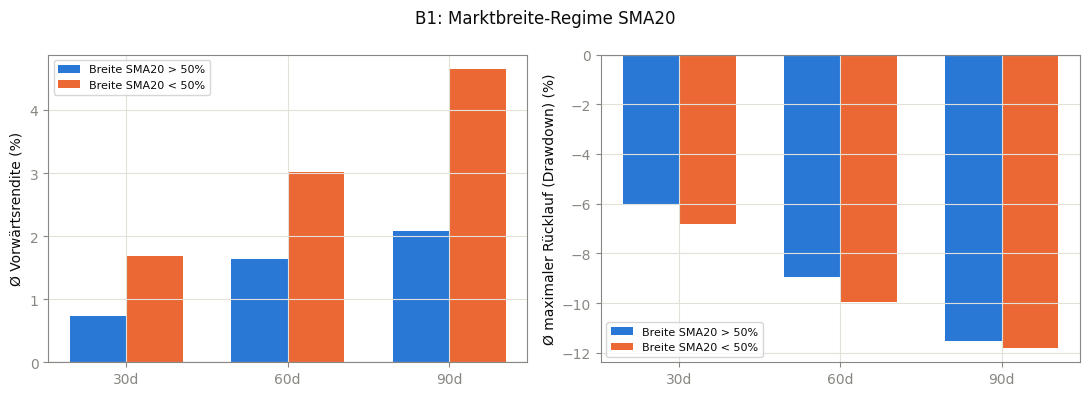

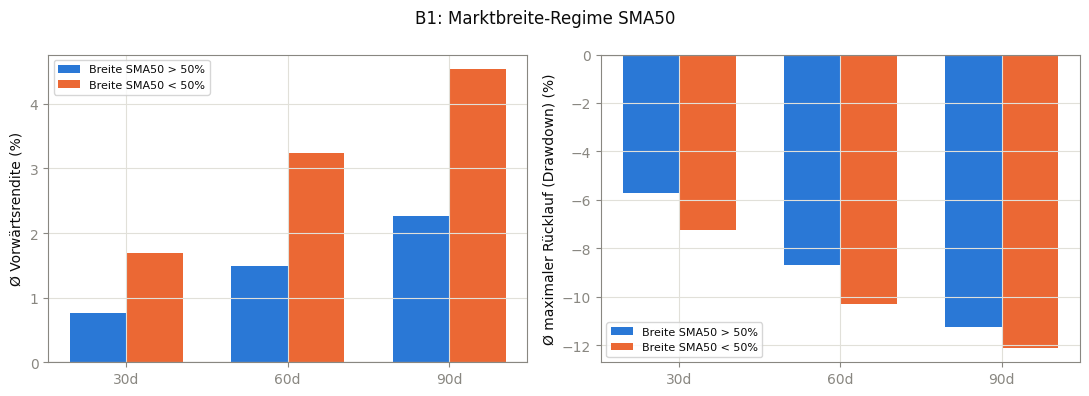

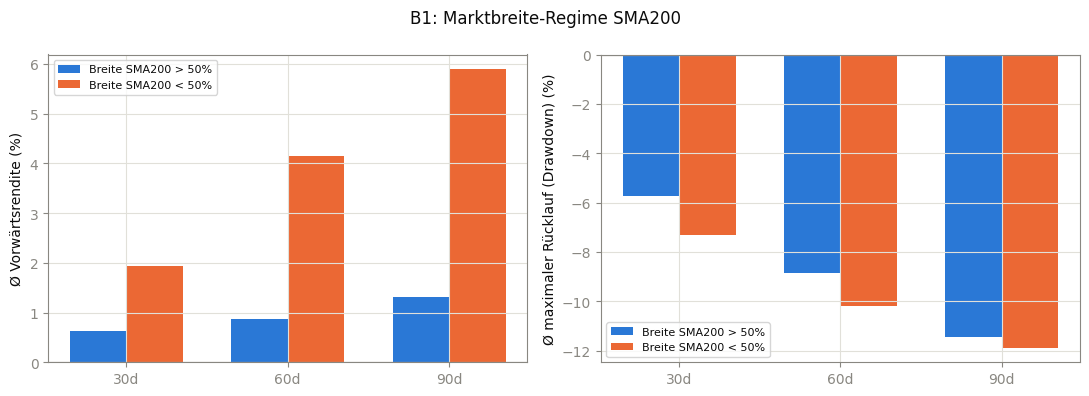

In [13]:
# Diagramm je Fenster
for w in BREADTH_WINDOWS:
    plotte_gruppenvergleich(tabelle_b1[tabelle_b1["sma_fenster"] == w], f"B1: Marktbreite-Regime SMA{w}")


**Ergebnis:** Hier zeigt sich ein anderes Bild als beim Risikosignal, das man
zunächst vermuten würde: Das **Renditesignal** ist über alle drei Fenster
durchgehend signifikant (9 von 9 Kombinationen) - notiert die Mehrheit der
Mitglieder über ihrem SMA (Breite > 50 %), fällt die mittlere
Vorwärtsrendite **niedriger** aus als bei Breite < 50 % (Mean-Reversion,
z. B. SMA20/90 Tage: 2,1 % gegenüber 4,7 %). Das **Risikosignal** ist dagegen
nur teilweise signifikant (7 von 9 Kombinationen): Notiert die Mehrheit
unter ihrem SMA, ist der nachfolgende maximale Rücklauf des Gesamtindex in
den meisten Fenstern und Horizonten stärker als bei Breite > 50 % (z. B.
SMA50/30 Tage: -5,7 % gegenüber -7,3 %), bei den jeweils längsten Horizonten
(SMA20/90 Tage und SMA200/90 Tage) verfehlt der Unterschied jedoch knapp die
Signifikanzschwelle. Anders als man aus dem reinen Niveau-Signal erwarten
würde, ist die Marktbreite beim Russell 2000 auf B1-Ebene damit ein
**robusteres Rendite- als Risikosignal** - die Richtung folgt in beiden
Fällen einem Mean-Reversion-Muster: Starke Breite geht im Mittel mit
niedrigerer Folgerendite und (etwas weniger durchgängig) geringerem Risiko
einher.


### 4.2 B2 - Richtung der Marktbreite (steigend vs. fallend)

**Hypothese:** Unabhängig vom Niveau der Marktbreite könnte bereits ihre
Richtung (nimmt die Beteiligung gerade zu oder ab?) Information über die
Folgeperiode liefern.


In [14]:
def breite_richtung(fenster: int) -> tuple[pd.Series, pd.Series]:
    breite_diff = df[f"breite_sma{fenster}"].diff()
    steigend = breite_diff > 0
    fallend = breite_diff <= 0
    return steigend, fallend


ergebnisse_b2 = []
for w in BREADTH_WINDOWS:
    steigend, fallend = breite_richtung(w)
    for h in HORIZONS:
        for ziel in ["fwd_return", "fwd_mdd"]:
            res = vergleiche_gruppen(
                df.loc[steigend, f"{ziel}_{h}d"], df.loc[fallend, f"{ziel}_{h}d"],
                label_a=f"Breite SMA{w} steigend", label_b=f"Breite SMA{w} fallend",
            )
            if res:
                res.update({"sma_fenster": w, "horizont_tage": h, "zielgröße": ziel})
                ergebnisse_b2.append(res)

tabelle_b2 = ergebnisse_zu_tabelle(ergebnisse_b2)
alle_ergebnisse["B2_Breite_Richtung"] = tabelle_b2
tabelle_b2[spalten_anzeige]


,sma_fenster,horizont_tage,zielgröße,label_a,mean_a,label_b,mean_b,t_pvalue,u_pvalue,signifikant_5pct
0,20,30,fwd_return,Breite SMA20 steigend,0.0116,Breite SMA20 fallend,0.0122,0.8126,0.5955,False
1,20,30,fwd_mdd,Breite SMA20 steigend,-0.0634,Breite SMA20 fallend,-0.0649,0.3826,0.2967,False
2,20,60,fwd_return,Breite SMA20 steigend,0.0228,Breite SMA20 fallend,0.0232,0.8994,0.9358,False
3,20,60,fwd_mdd,Breite SMA20 steigend,-0.0938,Breite SMA20 fallend,-0.0951,0.5565,0.5376,False
4,20,90,fwd_return,Breite SMA20 steigend,0.0323,Breite SMA20 fallend,0.0341,0.6724,0.4889,False
5,20,90,fwd_mdd,Breite SMA20 steigend,-0.1154,Breite SMA20 fallend,-0.1175,0.4130,0.4630,False
6,50,30,fwd_return,Breite SMA50 steigend,0.0103,Breite SMA50 fallend,0.0135,0.1899,0.1087,False
7,50,30,fwd_mdd,Breite SMA50 steigend,-0.0636,Breite SMA50 fallend,-0.0648,0.4806,0.3749,False
8,50,60,fwd_return,Breite SMA50 steigend,0.0227,Breite SMA50 fallend,0.0233,0.8542,0.9677,False
9,50,60,fwd_mdd,Breite SMA50 steigend,-0.0929,Breite SMA50 fallend,-0.0960,0.1589,0.1028,False


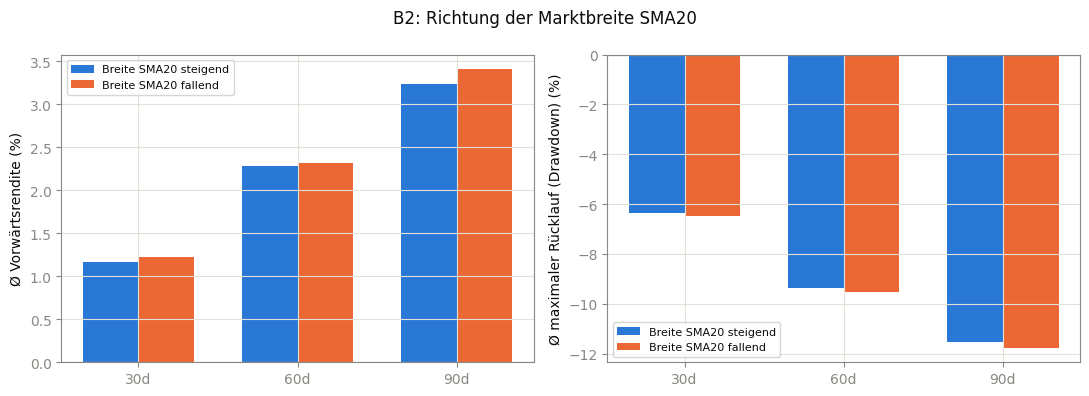

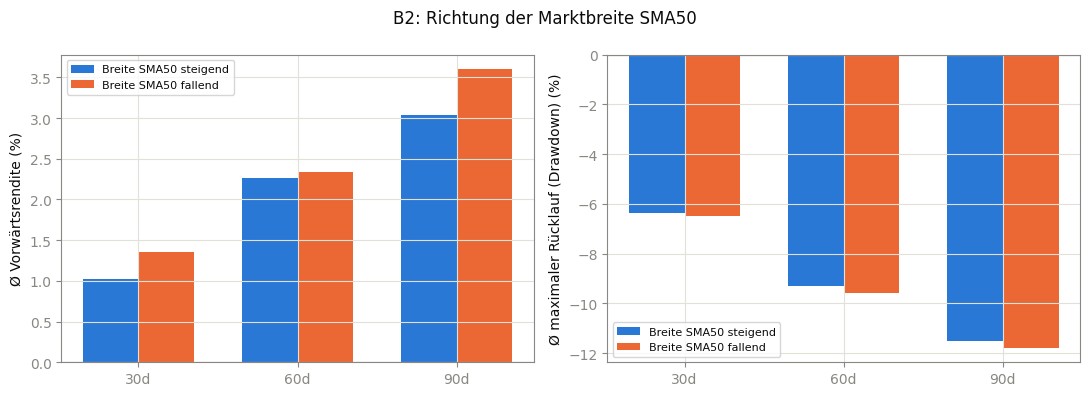

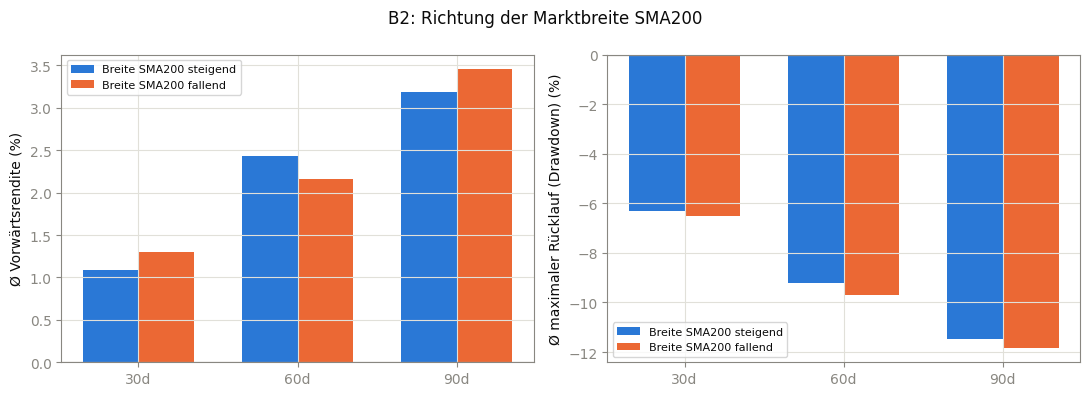

In [15]:
for w in BREADTH_WINDOWS:
    plotte_gruppenvergleich(tabelle_b2[tabelle_b2["sma_fenster"] == w], f"B2: Richtung der Marktbreite SMA{w}")


**Ergebnis:** Anders als das *Niveau* der Marktbreite (B1) liefert ihre
*Richtung* praktisch keine eigenständige Information: Von 18 geprüften
Kombinationen ist nur eine einzige signifikant (SMA200, 60-Tage-Drawdown:
-9,2 % bei steigender gegenüber -9,7 % bei fallender Breite). Beim
Renditesignal - bei B1 durchgehend robust - zeigt sich bei B2 in keiner
einzigen der neun Kombinationen ein signifikanter Unterschied zwischen
steigender und fallender Breite. Anders als beim Niveau der Marktbreite
lässt sich aus ihrer Richtung damit kein belastbares Signal ableiten -
vermutlich, weil die tägliche Richtungsänderung einer bereits stark
geglätteten Prozentkennzahl in hohem Maß Rauschen statt Trend abbildet.


### 4.3 B3 - Marktbreite in Quartilen

**Hypothese:** Die Wirkung der Marktbreite ist nicht binär, sondern
graduell abgestuft: Je höher die Breite (Q4 = 75-100 %), desto günstiger
das Rendite-/Risikoprofil der Folgeperiode; je niedriger (Q1 = 0-25 %), desto
ungünstiger. Getestet wird mit einem Kruskal-Wallis-Omnibustest über alle
vier Quartile sowie einem paarweisen Extremvergleich Q1 vs. Q4.


In [16]:
def breite_quartil(fenster: int) -> pd.Series:
    breite = df[f"breite_sma{fenster}"]
    return pd.cut(breite, bins=QUARTIL_GRENZEN, labels=QUARTIL_LABELS, include_lowest=True)


ergebnisse_b3 = []
for w in BREADTH_WINDOWS:
    quartil = breite_quartil(w)
    df[f"Quartil_SMA{w}"] = quartil
    print(f"SMA{w} - Verteilung der Handelstage auf die Quartile:")
    print(quartil.value_counts().reindex(QUARTIL_LABELS))
    for h in HORIZONS:
        for ziel in ["fwd_return", "fwd_mdd"]:
            gruppen = {label: df.loc[quartil == label, f"{ziel}_{h}d"] for label in QUARTIL_LABELS}
            res = vergleiche_quartile(gruppen)
            if res:
                res.update({"sma_fenster": w, "horizont_tage": h, "zielgröße": ziel})
                ergebnisse_b3.append(res)

tabelle_b3 = ergebnisse_zu_tabelle(ergebnisse_b3)
alle_ergebnisse["B3_Breite_Quartile"] = tabelle_b3
cols_b3 = ["sma_fenster", "horizont_tage", "zielgröße"] + [f"mean_{l}" for l in QUARTIL_LABELS] + \
          ["kw_pvalue", "kw_signifikant_5pct", "q1_vs_q4_signifikant_5pct"]
tabelle_b3[cols_b3]


SMA20 - Verteilung der Handelstage auf die Quartile:
breite_sma20
Q1 (0-25%)       403
Q2 (25-50%)     1131
Q3 (50-75%)     1285
Q4 (75-100%)     399
Name: count, dtype: int64
SMA50 - Verteilung der Handelstage auf die Quartile:
breite_sma50
Q1 (0-25%)       346
Q2 (25-50%)     1122
Q3 (50-75%)     1493
Q4 (75-100%)     257
Name: count, dtype: int64
SMA200 - Verteilung der Handelstage auf die Quartile:
breite_sma200
Q1 (0-25%)       220
Q2 (25-50%)     1161
Q3 (50-75%)     1611
Q4 (75-100%)     226
Name: count, dtype: int64


,sma_fenster,horizont_tage,zielgröße,mean_Q1 (0-25%),mean_Q2 (25-50%),mean_Q3 (50-75%),mean_Q4 (75-100%),kw_pvalue,kw_signifikant_5pct,q1_vs_q4_signifikant_5pct
0,20,30,fwd_return,0.0286,0.0127,0.0045,0.0164,0.0000,True,True
1,20,30,fwd_mdd,-0.0766,-0.0652,-0.0607,-0.0595,0.0004,True,True
2,20,60,fwd_return,0.0575,0.0203,0.0081,0.0424,0.0000,True,True
3,20,60,fwd_mdd,-0.1038,-0.0982,-0.0936,-0.0771,0.0000,True,True
4,20,90,fwd_return,0.0825,0.0333,0.0114,0.0509,0.0000,True,True
5,20,90,fwd_mdd,-0.1182,-0.1178,-0.1206,-0.0979,0.0036,True,True
6,50,30,fwd_return,0.0370,0.0107,0.0062,0.0162,0.0000,True,True
7,50,30,fwd_mdd,-0.0870,-0.0680,-0.0570,-0.0572,0.0000,True,True
8,50,60,fwd_return,0.0823,0.0169,0.0096,0.0446,0.0000,True,True
9,50,60,fwd_mdd,-0.1094,-0.1012,-0.0897,-0.0712,0.0000,True,True


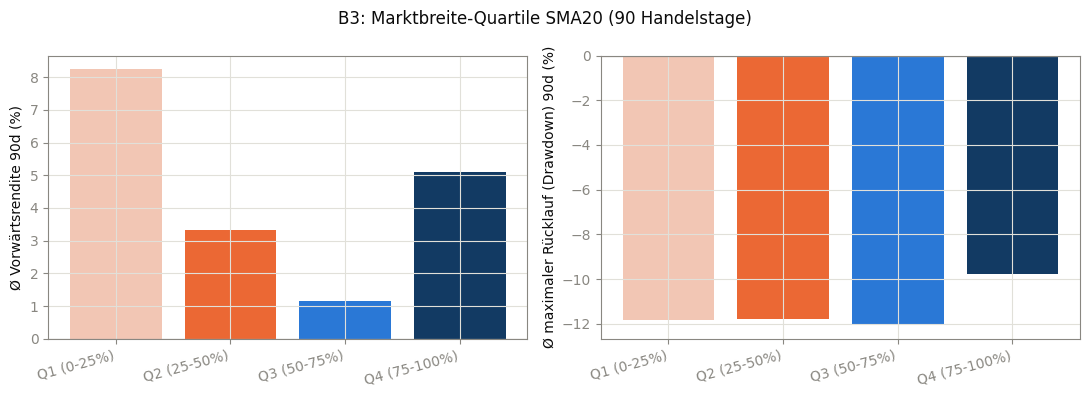

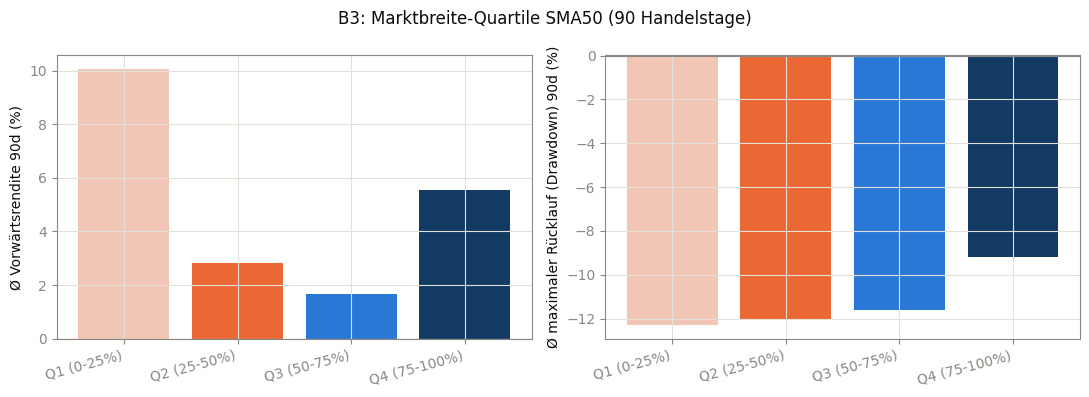

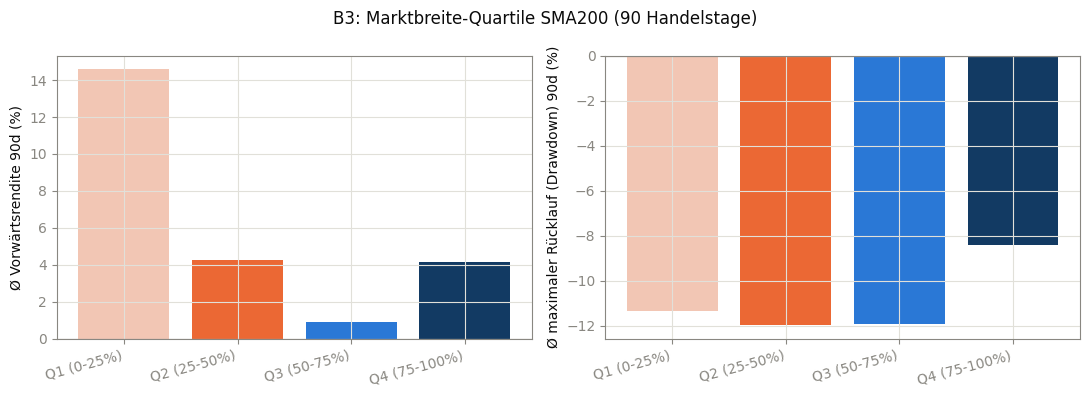

In [17]:
for w in BREADTH_WINDOWS:
    teil_b3 = tabelle_b3[tabelle_b3["sma_fenster"] == w]
    plotte_quartile(teil_b3, 90, f"B3: Marktbreite-Quartile SMA{w} (90 Handelstage)")


**Ergebnis:** Alle 18 Kruskal-Wallis-Omnibustests sowie alle 18 paarweisen
Q1-vs-Q4-Vergleiche sind signifikant - die Marktbreite differenziert die
Folgeperiode in jedem Fenster und Horizont über die vier Quartile hinweg.
Bei der Rendite dominiert vor allem Q1: Die extrem schwache Breite in Q1
geht durchgehend mit der **höchsten** mittleren Vorwärtsrendite aller vier
Quartile einher (SMA200/90 Tage: 14,6 % gegenüber 0,9-4,2 % in Q2-Q4;
SMA20/90 Tage: 8,2 % gegenüber 1,1-5,1 %) - ein deutlicher
Extremquartil-Effekt. Beim Risiko ist Q4 (stärkste Breite) in allen
Fenstern und Horizonten durchgehend das sicherste Quartil (z. B. SMA200/90
Tage: -8,4 % gegenüber -9,1 bis -12,0 % in Q1-Q3); ein sauberer monotoner
Gradient von Q1 bis Q4 zeigt sich jedoch nur bei SMA50 - bei SMA20 und
SMA200 liegt das höchste Risiko nicht in Q1, sondern in den mittleren
Quartilen Q2/Q3 (z. B. SMA200/90 Tage: Q1 -11,4 %, Q2 -12,0 %, Q3
-11,9 %, Q4 -8,4 %). Anders als eine einfache "je schwächer die Breite,
desto riskanter"-Erwartung zeigt sich beim Risiko damit vor allem ein klarer
Vorteil des obersten Quartils, während die schwächste Breite (Q1) zugleich
die höchste erwartete Rendite liefert - ein Extremquartil-Effekt bei der
Rendite, aber kein durchgehend monotoner beim Risiko.


### 4.4 B4 - Frühindikator Krise

**Hypothese:** Ausgangslage ist eine breit getragene Rally (SMA200-Breite
> 75 %, bei intaktem SMA20-Breitewert von mindestens 50 %). Fällt die
schnelle SMA20-Breite anschließend unter 50 %, während die träge
SMA200-Breite selbst noch nicht unter 50 % gefallen ist, deutet dies auf eine
beginnende, aber von der breiten Marktlage noch nicht bestätigte Abkühlung
hin - ein möglicher Frühindikator für eine bevorstehende Krise.


In [18]:
def frühindikator_krise(breite_sma20: pd.Series, breite_sma200: pd.Series) -> pd.Series:
    '''Signalisiert den Tag, an dem die SMA20-Breite erstmals unter 50 %
    fällt, nachdem die SMA200-Breite zuvor (bei damals noch >= 50 % liegender
    SMA20-Breite) das obere Quartil (> 75 %) erreicht hatte und selbst noch
    nicht unter 50 % gefallen ist.'''
    signal = pd.Series(False, index=breite_sma20.index)
    war_oben = False
    for datum in breite_sma20.index:
        b20, b200 = breite_sma20[datum], breite_sma200[datum]
        if pd.isna(b20) or pd.isna(b200):
            continue
        if b200 <= 50:
            war_oben = False
            continue
        if b200 > 75 and b20 >= 50:
            war_oben = True
        if war_oben and b20 < 50:
            signal[datum] = True
            war_oben = False
    return signal


signal_b4 = frühindikator_krise(df["breite_sma20"], df["breite_sma200"])
n_b4 = int(signal_b4.sum())
print(f"B4-Ereignisse identifiziert: {n_b4}")
if n_b4 > 0:
    print(df.index[signal_b4].date)


B4-Ereignisse identifiziert: 20
[datetime.date(2013, 11, 1) datetime.date(2013, 12, 10)
 datetime.date(2014, 1, 13) datetime.date(2014, 1, 24)
 datetime.date(2016, 9, 9) datetime.date(2016, 9, 26)
 datetime.date(2016, 12, 30) datetime.date(2017, 1, 5)
 datetime.date(2021, 1, 4) datetime.date(2021, 1, 27)
 datetime.date(2021, 2, 26) datetime.date(2021, 3, 4)
 datetime.date(2021, 3, 23) datetime.date(2021, 4, 19)
 datetime.date(2021, 5, 5) datetime.date(2021, 5, 10)
 datetime.date(2021, 5, 18) datetime.date(2021, 5, 25)
 datetime.date(2021, 6, 17) datetime.date(2021, 6, 25)]


In [19]:
ergebnisse_b4 = []
if n_b4 >= 10:
    for h in HORIZONS:
        for ziel in ["fwd_return", "fwd_mdd"]:
            res = vergleiche_gruppen(
                df.loc[signal_b4, f"{ziel}_{h}d"], df[f"{ziel}_{h}d"],
                label_a="B4-Signal", label_b="Basisrate (alle Tage)",
            )
            if res:
                res.update({"horizont_tage": h, "zielgröße": ziel, "n_events": n_b4})
                ergebnisse_b4.append(res)
    tabelle_b4 = ergebnisse_zu_tabelle(ergebnisse_b4)
else:
    # Zu wenige Ereignisse für einen belastbaren Test - Einzelereignisse
    # werden stattdessen deskriptiv mit ihrer tatsächlichen Folgeentwicklung
    # aufgelistet.
    einzelereignisse = df.loc[signal_b4, [f"fwd_return_{h}d" for h in HORIZONS] + [f"fwd_mdd_{h}d" for h in HORIZONS]]
    tabelle_b4 = einzelereignisse.reset_index()
    print(f"Nur {n_b4} Ereignisse - deskriptive Einzelbetrachtung statt Signifikanztest:")

alle_ergebnisse["B4_Frühindikator_Krise"] = tabelle_b4
tabelle_b4


,label_a,n_a,mean_a,median_a,std_a,label_b,n_b,mean_b,median_b,std_b,t_pvalue,u_pvalue,signifikant_5pct,horizont_tage,zielgröße,n_events
0,B4-Signal,20,0.0284,0.0238,0.0455,Basisrate (alle Tage),3188,0.0119,0.0156,0.0704,0.1236,0.2875,False,30,fwd_return,20
1,B4-Signal,20,-0.0570,-0.0465,0.0234,Basisrate (alle Tage),3188,-0.0642,-0.0519,0.0475,0.1948,0.9770,False,30,fwd_mdd,20
2,B4-Signal,20,0.0279,0.0113,0.0522,Basisrate (alle Tage),3158,0.0230,0.0251,0.0960,0.6822,0.9769,False,60,fwd_return,20
3,B4-Signal,20,-0.0803,-0.0858,0.0157,Basisrate (alle Tage),3158,-0.0944,-0.0817,0.0622,0.0008,0.9410,False,60,fwd_mdd,20
4,B4-Signal,20,0.0346,0.0177,0.0429,Basisrate (alle Tage),3128,0.0332,0.0319,0.1153,0.8872,0.9893,False,90,fwd_return,20
5,B4-Signal,20,-0.0852,-0.0909,0.0139,Basisrate (alle Tage),3128,-0.1165,-0.0912,0.0720,0.0000,0.1817,False,90,fwd_mdd,20


**Ergebnis:** Mit 20 identifizierten Ereignissen zwischen November 2013 und
Juni 2021 liegt die Stichprobe knapp oberhalb der Mindestgröße für einen
Signifikanztest, jedoch deutlich niedriger als bei einem seit 2007
verfügbaren Datensatz zu erwarten wäre - eine direkte Folge der erst 2013
einsetzenden Marktbreite-Historie. Keiner der sechs Vergleiche ist
signifikant (p zwischen 0,12 und 0,98). Der Richtung nach zeigt sich jedoch
durchgehend dasselbe Muster wie bei den übrigen Hypothesen dieses
Notebooks: Der maximale Vorwärtsrücklauf fällt nach dem Signal in allen drei
Horizonten **kleiner** aus als die Basisrate (30 Tage: -5,7 % gegenüber
-6,4 %; 60 Tage: -8,0 % gegenüber -9,4 %; 90 Tage: -8,5 % gegenüber
-11,6 %), die Vorwärtsrendite liegt zugleich leicht **höher** als die
Basisrate (30 Tage: 2,8 % gegenüber 1,2 %; 90 Tage: 3,5 % gegenüber
3,3 %). Die als Frühindikator einer Krise formulierte Hypothese lässt sich
in den Russell-2000-Daten damit **nicht statistisch bestätigen** - die
kurze Marktbreite-Historie liefert mit 20 Ereignissen zwar keine
ausreichend große Stichprobe für einen belastbaren Test, die durchgängig
gleiche Richtung des Effekts spricht aber gegen die Hypothese eines echten
Frühwarnsignals und eher für eine gesunde Verschnaufpause innerhalb eines
laufenden Aufwärtstrends.


### 4.5 B5 - Frühindikator Erholung

**Hypothese:** Spiegelbild zu B4. Ausgangslage ist eine breit unterstützte
Schwächephase (SMA200-Breite < 25 %, bei damals noch schwacher
SMA20-Breite <= 50 %). Steigt die schnelle SMA20-Breite anschließend über
50 %, während die SMA200-Breite selbst noch nicht über 50 % gestiegen ist,
deutet dies auf eine beginnende, breitenseitig noch nicht bestätigte
Erholung hin.


In [20]:
def frühindikator_erholung(breite_sma20: pd.Series, breite_sma200: pd.Series) -> pd.Series:
    signal = pd.Series(False, index=breite_sma20.index)
    war_unten = False
    for datum in breite_sma20.index:
        b20, b200 = breite_sma20[datum], breite_sma200[datum]
        if pd.isna(b20) or pd.isna(b200):
            continue
        if b200 >= 50:
            war_unten = False
            continue
        if b200 < 25 and b20 <= 50:
            war_unten = True
        if war_unten and b20 > 50:
            signal[datum] = True
            war_unten = False
    return signal


signal_b5 = frühindikator_erholung(df["breite_sma20"], df["breite_sma200"])
n_b5 = int(signal_b5.sum())
print(f"B5-Ereignisse identifiziert: {n_b5}")
if n_b5 > 0:
    print(df.index[signal_b5].date)


B5-Ereignisse identifiziert: 12
[datetime.date(2016, 1, 29) datetime.date(2016, 2, 16)
 datetime.date(2019, 1, 4) datetime.date(2020, 4, 6)
 datetime.date(2020, 5, 18) datetime.date(2022, 5, 26)
 datetime.date(2022, 7, 7) datetime.date(2022, 7, 15)
 datetime.date(2022, 10, 13) datetime.date(2022, 10, 17)
 datetime.date(2023, 11, 2) datetime.date(2025, 4, 24)]


In [21]:
ergebnisse_b5 = []
if n_b5 >= 10:
    for h in HORIZONS:
        for ziel in ["fwd_return", "fwd_mdd"]:
            res = vergleiche_gruppen(
                df.loc[signal_b5, f"{ziel}_{h}d"], df[f"{ziel}_{h}d"],
                label_a="B5-Signal", label_b="Basisrate (alle Tage)",
            )
            if res:
                res.update({"horizont_tage": h, "zielgröße": ziel, "n_events": n_b5})
                ergebnisse_b5.append(res)
    tabelle_b5 = ergebnisse_zu_tabelle(ergebnisse_b5)
else:
    einzelereignisse = df.loc[signal_b5, [f"fwd_return_{h}d" for h in HORIZONS] + [f"fwd_mdd_{h}d" for h in HORIZONS]]
    tabelle_b5 = einzelereignisse.reset_index()
    print(f"Nur {n_b5} Ereignisse - deskriptive Einzelbetrachtung statt Signifikanztest:")

alle_ergebnisse["B5_Frühindikator_Erholung"] = tabelle_b5
tabelle_b5


,label_a,n_a,mean_a,median_a,std_a,label_b,n_b,mean_b,median_b,std_b,t_pvalue,u_pvalue,signifikant_5pct,horizont_tage,zielgröße,n_events
0,B5-Signal,12,0.0899,0.0892,0.0590,Basisrate (alle Tage),3188,0.0119,0.0156,0.0704,0.0008,0.0001,True,30,fwd_return,12
1,B5-Signal,12,-0.0623,-0.0491,0.0379,Basisrate (alle Tage),3188,-0.0642,-0.0519,0.0475,0.8664,0.9923,False,30,fwd_mdd,12
2,B5-Signal,12,0.0976,0.1154,0.0872,Basisrate (alle Tage),3158,0.0230,0.0251,0.0960,0.0130,0.0044,True,60,fwd_return,12
3,B5-Signal,12,-0.0999,-0.0902,0.0493,Basisrate (alle Tage),3158,-0.0944,-0.0817,0.0622,0.7110,0.4414,False,60,fwd_mdd,12
4,B5-Signal,12,0.1318,0.1126,0.1044,Basisrate (alle Tage),3128,0.0332,0.0319,0.1153,0.0075,0.0013,True,90,fwd_return,12
5,B5-Signal,12,-0.1059,-0.0902,0.0502,Basisrate (alle Tage),3128,-0.1165,-0.0912,0.0720,0.4802,0.7314,False,90,fwd_mdd,12


**Ergebnis:** 12 Ereignisse zwischen Januar 2016 und April 2025, historisch
plausibel rund um reale Bodenbildungsphasen konzentriert (Anfang 2016,
Anfang 2019, Frühjahr 2020, mehrfach 2022, Ende 2023, Frühjahr 2025). Die
Vorwärtsrendite liegt im Mittel deutlich und in allen drei Horizonten
**signifikant höher** als die Basisrate (30 Tage: 9,0 % gegenüber 1,2 %;
60 Tage: 9,8 % gegenüber 2,3 %; 90 Tage: 13,2 % gegenüber 3,3 %). Beim
Risiko zeigt sich dagegen in keinem Horizont ein signifikanter Unterschied,
und die Richtung ist uneinheitlich: Bei 30 und 90 Tagen fällt der maximale
Vorwärtsrücklauf nach dem Signal sogar leicht **kleiner** aus als die
Basisrate (30 Tage: -6,2 % gegenüber -6,4 %; 90 Tage: -10,6 % gegenüber
-11,6 %), bei 60 Tagen geringfügig größer (-10,0 % gegenüber -9,4 %). Das
Signal markiert damit in den Russell-2000-Daten einen klar überdurchschnittlich
starken Erholungsimpuls bei gleichzeitig unauffälligem Risiko - anders als
eine reine "unruhige Bodenbildung ohne Risikoentlastung" liefert B5 hier ein
eigenständiges, positiv gerichtetes Renditesignal ohne erkennbaren
Risikoaufschlag.


### 4.6 Gemeinsames Vorgehen für B6-B9

Die folgenden vier Hypothesen basieren alle auf punktuellen Ereignissen
(Schwellenkreuzungen). Sie werden mit derselben Funktion ausgewertet: Bei
mindestens 10 Ereignissen wird das Ereignis gegen die Basisrate (alle
Handelstage) getestet, bei weniger Ereignissen erfolgt eine deskriptive
Auflistung der Einzelereignisse.


In [22]:
def ereignis_hypothese(event: pd.Series, label: str, extra: dict) -> tuple[list[dict], pd.DataFrame | None]:
    '''Testet ein Ereignis (event=True an den Signaltagen) gegen die
    Basisrate aller Handelstage. Liefert (Ergebnisliste, None) bei
    ausreichender Stichprobe, sonst (leere Liste, Tabelle der
    Einzelereignisse) zur deskriptiven Auflistung.'''
    n = int(event.sum())
    if n >= 10:
        ergebnisse = []
        for h in HORIZONS:
            for ziel in ["fwd_return", "fwd_mdd"]:
                res = vergleiche_gruppen(
                    df.loc[event, f"{ziel}_{h}d"], df[f"{ziel}_{h}d"],
                    label_a=label, label_b="Basisrate (alle Tage)",
                )
                if res:
                    res.update({**extra, "horizont_tage": h, "zielgröße": ziel, "n_events": n})
                    ergebnisse.append(res)
        return ergebnisse, None
    else:
        spalten = [f"fwd_return_{h}d" for h in HORIZONS] + [f"fwd_mdd_{h}d" for h in HORIZONS]
        einzel = df.loc[event, spalten].reset_index()
        for k, v in extra.items():
            einzel[k] = v
        return [], einzel


print("Gemeinsame Ereignis-Testfunktion definiert.")


Gemeinsame Ereignis-Testfunktion definiert.


### 4.7 B6 - Wochentrend positiv, Marktbreite bricht ein

**Hypothese:** Steigt der Index auf Wochenbasis (Kurs > SMA50_w, ca. 1 Jahr),
die Marktbreite je SMA-Fenster jedoch gleichzeitig (a) aus dem oberen
Quartil heraus oder (b) unter 50 % - deutet dies auf eine zunehmend schmaler
getragene Rally hin, obwohl der Index selbst noch keinen Trendbruch zeigt.
Jedes Fenster (SMA20/50/200) wird einzeln betrachtet.


In [23]:
def kreuzt_abwärts(reihe: pd.Series, schwelle: float) -> pd.Series:
    vorher = reihe.shift(1)
    return (vorher >= schwelle) & (reihe < schwelle)


wochentrend_positiv = df["Wochentrend_positiv"] == 1

ergebnisse_b6 = []
deskriptiv_b6 = []
n_events_b6 = {}
for w in BREADTH_WINDOWS:
    breite = df[f"breite_sma{w}"]
    for schwelle, bezeichnung in [(75, "verlässt oberes Quartil (75%)"), (50, "fällt unter 50%")]:
        event = kreuzt_abwärts(breite, schwelle) & wochentrend_positiv
        label = f"B6 SMA{w} {bezeichnung}"
        n_events_b6[label] = int(event.sum())
        ergebnisse, deskriptiv = ereignis_hypothese(
            event, label, {"sma_fenster": w, "schwelle": schwelle, "bezeichnung": bezeichnung},
        )
        ergebnisse_b6.extend(ergebnisse)
        if deskriptiv is not None:
            deskriptiv_b6.append(deskriptiv)

print("Ereignishäufigkeit je Parametrisierung:")
for label, n in n_events_b6.items():
    print(f"  {label:.<55s} {n}")

tabelle_b6 = ergebnisse_zu_tabelle(ergebnisse_b6)
alle_ergebnisse["B6_Wochentrend_positiv_Breiteneinbruch"] = tabelle_b6
tabelle_deskriptiv_b6 = pd.concat(deskriptiv_b6, ignore_index=True) if deskriptiv_b6 else pd.DataFrame()
if not tabelle_b6.empty:
    display(tabelle_b6[["sma_fenster", "bezeichnung", "n_events", "horizont_tage", "zielgröße",
                         "mean_a", "mean_b", "t_pvalue", "u_pvalue", "signifikant_5pct"]])
if not tabelle_deskriptiv_b6.empty:
    print("\nDeskriptiv (weniger als 10 Ereignisse):")
    display(tabelle_deskriptiv_b6)


Ereignishäufigkeit je Parametrisierung:
  B6 SMA20 verlässt oberes Quartil (75%)................. 70
  B6 SMA20 fällt unter 50%............................... 166
  B6 SMA50 verlässt oberes Quartil (75%)................. 33
  B6 SMA50 fällt unter 50%............................... 103
  B6 SMA200 verlässt oberes Quartil (75%)................ 18
  B6 SMA200 fällt unter 50%.............................. 69


,sma_fenster,bezeichnung,n_events,horizont_tage,zielgröße,mean_a,mean_b,t_pvalue,u_pvalue,signifikant_5pct
0,20,verlässt oberes Quartil (75%),70,30,fwd_return,0.0099,0.0119,0.7498,0.8349,False
1,20,verlässt oberes Quartil (75%),70,30,fwd_mdd,-0.0565,-0.0642,0.0398,0.4659,False
2,20,verlässt oberes Quartil (75%),70,60,fwd_return,0.0268,0.0230,0.6967,0.9348,False
3,20,verlässt oberes Quartil (75%),70,60,fwd_mdd,-0.0754,-0.0944,0.0000,0.0232,True
4,20,verlässt oberes Quartil (75%),70,90,fwd_return,0.0230,0.0332,0.4556,0.5140,False
5,20,verlässt oberes Quartil (75%),70,90,fwd_mdd,-0.1041,-0.1165,0.0922,0.4603,False
6,20,fällt unter 50%,166,30,fwd_return,0.0066,0.0119,0.3676,0.5426,False
7,20,fällt unter 50%,166,30,fwd_mdd,-0.0643,-0.0642,0.9732,0.9686,False
8,20,fällt unter 50%,166,60,fwd_return,0.0157,0.0230,0.3427,0.5241,False
9,20,fällt unter 50%,166,60,fwd_mdd,-0.0947,-0.0944,0.9646,0.9091,False


**Ergebnis:** Alle sechs Parametrisierungen sind mit 18 bis 166 Ereignissen
gut testbar. Die Rendite unterscheidet sich nur in einer der 18
Kombinationen signifikant von der Basisrate (SMA200 "fällt unter 50 %",
90 Tage: 6,7 % gegenüber 3,3 % - **höher**, nicht niedriger). Beim Risiko
zeigt sich ein signifikanter Unterschied in 5 von 18 Kombinationen, über
alle drei Fenster verteilt - und zwar durchgehend in die dem Hypothesentext
**entgegengesetzte** Richtung: Der nachfolgende maximale Rücklauf fällt
nach dem Signal kleiner (nicht größer) aus als die Basisrate (z. B. SMA200
"verlässt oberes Quartil", 90 Tage: -7,5 % gegenüber -11,6 %; SMA50
"verlässt oberes Quartil", 60 Tage: -6,8 % gegenüber -9,4 %). Ein sich
abschwächender, aber noch positiver Wochentrend liefert damit kein
belastbares Frühwarnsignal über eine schmaler werdende Rally - soweit
überhaupt ein Effekt sichtbar wird, deutet er (wie bereits bei B4) eher auf
eine gesunde Verschnaufpause hin.


### 4.8 B7 - Wochentrend negativ, Marktbreite stabilisiert sich

**Hypothese:** Spiegelbild zu B6. Fällt der Index auf Wochenbasis (Kurs <=
SMA50_w), die Marktbreite je SMA-Fenster jedoch (a) aus dem unteren Quartil
heraus oder (b) über 50 % - deutet dies auf eine zunehmend breiter
getragene Stabilisierung hin, obwohl der Index selbst noch keinen
Trendwechsel zeigt.


In [24]:
def kreuzt_aufwärts(reihe: pd.Series, schwelle: float) -> pd.Series:
    vorher = reihe.shift(1)
    return (vorher <= schwelle) & (reihe > schwelle)


wochentrend_negativ = df["Wochentrend_positiv"] == 0

ergebnisse_b7 = []
deskriptiv_b7 = []
n_events_b7 = {}
for w in BREADTH_WINDOWS:
    breite = df[f"breite_sma{w}"]
    for schwelle, bezeichnung in [(25, "verlässt unteres Quartil (25%)"), (50, "steigt über 50%")]:
        event = kreuzt_aufwärts(breite, schwelle) & wochentrend_negativ
        label = f"B7 SMA{w} {bezeichnung}"
        n_events_b7[label] = int(event.sum())
        ergebnisse, deskriptiv = ereignis_hypothese(
            event, label, {"sma_fenster": w, "schwelle": schwelle, "bezeichnung": bezeichnung},
        )
        ergebnisse_b7.extend(ergebnisse)
        if deskriptiv is not None:
            deskriptiv_b7.append(deskriptiv)

print("Ereignishäufigkeit je Parametrisierung:")
for label, n in n_events_b7.items():
    print(f"  {label:.<55s} {n}")

tabelle_b7 = ergebnisse_zu_tabelle(ergebnisse_b7)
alle_ergebnisse["B7_Wochentrend_negativ_Breitenstabilisierung"] = tabelle_b7
tabelle_deskriptiv_b7 = pd.concat(deskriptiv_b7, ignore_index=True) if deskriptiv_b7 else pd.DataFrame()
if not tabelle_b7.empty:
    display(tabelle_b7[["sma_fenster", "bezeichnung", "n_events", "horizont_tage", "zielgröße",
                         "mean_a", "mean_b", "t_pvalue", "u_pvalue", "signifikant_5pct"]])
if not tabelle_deskriptiv_b7.empty:
    print("\nDeskriptiv (weniger als 10 Ereignisse):")
    display(tabelle_deskriptiv_b7)


Ereignishäufigkeit je Parametrisierung:
  B7 SMA20 verlässt unteres Quartil (25%)................ 61
  B7 SMA20 steigt über 50%............................... 56
  B7 SMA50 verlässt unteres Quartil (25%)................ 38
  B7 SMA50 steigt über 50%............................... 31
  B7 SMA200 verlässt unteres Quartil (25%)............... 15
  B7 SMA200 steigt über 50%.............................. 3


,sma_fenster,bezeichnung,n_events,horizont_tage,zielgröße,mean_a,mean_b,t_pvalue,u_pvalue,signifikant_5pct
0,20,verlässt unteres Quartil (25%),61,30,fwd_return,0.0191,0.0119,0.4860,0.4235,False
1,20,verlässt unteres Quartil (25%),61,30,fwd_mdd,-0.0818,-0.0642,0.0068,0.0030,True
2,20,verlässt unteres Quartil (25%),61,60,fwd_return,0.0456,0.0230,0.0699,0.1358,False
3,20,verlässt unteres Quartil (25%),61,60,fwd_mdd,-0.1071,-0.0944,0.0390,0.0031,True
4,20,verlässt unteres Quartil (25%),61,90,fwd_return,0.0528,0.0332,0.2629,0.2637,False
5,20,verlässt unteres Quartil (25%),61,90,fwd_mdd,-0.1240,-0.1165,0.2709,0.0675,False
6,20,steigt über 50%,56,30,fwd_return,0.0179,0.0119,0.5718,0.5213,False
7,20,steigt über 50%,56,30,fwd_mdd,-0.0711,-0.0642,0.2634,0.2441,False
8,20,steigt über 50%,56,60,fwd_return,0.0312,0.0230,0.5081,0.3293,False
9,20,steigt über 50%,56,60,fwd_mdd,-0.1049,-0.0944,0.1695,0.1502,False



Deskriptiv (weniger als 10 Ereignisse):


,Date,fwd_return_30d,fwd_return_60d,fwd_return_90d,fwd_mdd_30d,fwd_mdd_60d,fwd_mdd_90d,sma_fenster,schwelle,bezeichnung
0,2016-04-19,0.0200,0.0543,0.0875,-0.0514,-0.0835,-0.0835,200,50,steigt über 50%
1,2016-04-22,0.0263,0.0469,0.0866,-0.0514,-0.0835,-0.0835,200,50,steigt über 50%
2,2016-05-24,0.0127,0.0894,0.1025,-0.0835,-0.0835,-0.0835,200,50,steigt über 50%


**Ergebnis:** Fünf der sechs Parametrisierungen sind mit 15 bis 61
Ereignissen testbar; die kleinste (SMA200 "steigt über 50 %") kommt mit nur
3 Ereignissen (19. und 22. April sowie 24. Mai 2016 - praktisch ein
zusammenhängender Vorfall) nicht über die Testschwelle und wird rein
deskriptiv geführt, nicht mit Signifikanztest. Von den 15 testbaren
Kombinationen ist die Rendite nur einmal signifikant (SMA200 "verlässt
unteres Quartil", 90 Tage: 8,9 % gegenüber 3,3 % Basisrate - **höher**).
Beim Risiko zeigt sich ein signifikanter Unterschied in 3 von 15
Kombinationen (SMA20 "verlässt unteres Quartil" bei 30 und 60 Tagen, SMA50
"steigt über 50 %" bei 60 Tagen) - und zwar durchgehend in dieselbe
unerwartete Richtung wie bei B5: Der maximale Vorwärtsrücklauf fällt
**größer** statt kleiner aus (z. B. SMA20 "verlässt unteres Quartil",
30 Tage: -8,2 % gegenüber -6,4 % Basisrate). Ein sich bereits aufhellender,
aber noch negativer Wochentrend geht damit dort, wo überhaupt ein
signifikanter Effekt sichtbar wird, historisch nicht mit einer
risikoärmeren Erholung einher, sondern mit erhöhter Volatilität -
inhaltlich dasselbe Muster wie bei B5, hier jedoch nur in einer Minderheit
der Parametrisierungen statistisch abgesichert.


### 4.9 B8 - Divergenz: Kurshoch ohne Breitenbestätigung

**Hypothese:** Erreicht der Index ein neues Hoch der letzten w Handelstage,
ist relevant, ob die zugehörige Marktbreite (SMA-Fenster w) diese Bewegung
bestätigt (in den letzten 10 Handelstagen gestiegen) oder nicht (gefallen
oder unverändert). Eine unbestätigte Rally (steigender Kurs, fallende
Beteiligung) gilt in der technischen Analyse als Warnsignal.


In [25]:
DIVERGENZ_LAG = 10

ergebnisse_b8 = []
deskriptiv_b8 = []
for w in BREADTH_WINDOWS:
    breite = df[f"breite_sma{w}"]
    kurshoch = df["Close"] >= df["Close"].rolling(window=w, min_periods=w).max()
    bestätigt = kurshoch & (breite > breite.shift(DIVERGENZ_LAG))
    nicht_bestätigt = kurshoch & (breite <= breite.shift(DIVERGENZ_LAG))
    print(f"SMA{w}: {int(kurshoch.sum())} {w}-Tage-Hochs, davon "
          f"{int(bestätigt.sum())} breitenbestätigt und {int(nicht_bestätigt.sum())} unbestätigt.")

    for h in HORIZONS:
        for ziel in ["fwd_return", "fwd_mdd"]:
            res = vergleiche_gruppen(
                df.loc[bestätigt, f"{ziel}_{h}d"], df.loc[nicht_bestätigt, f"{ziel}_{h}d"],
                label_a=f"{w}-Tage-Hoch, Breite bestätigt", label_b=f"{w}-Tage-Hoch, Breite nicht bestätigt",
            )
            if res:
                res.update({"sma_fenster": w, "horizont_tage": h, "zielgröße": ziel,
                             "n_bestätigt": int(bestätigt.sum()), "n_nicht_bestätigt": int(nicht_bestätigt.sum())})
                ergebnisse_b8.append(res)

    if int(bestätigt.sum()) < 10 or int(nicht_bestätigt.sum()) < 10:
        spalten = [f"fwd_return_{h}d" for h in HORIZONS] + [f"fwd_mdd_{h}d" for h in HORIZONS]
        einzel = df.loc[kurshoch, spalten + []].reset_index()
        einzel["sma_fenster"] = w
        einzel["breite_bestätigt"] = bestätigt.loc[kurshoch].values
        deskriptiv_b8.append(einzel)

tabelle_b8 = ergebnisse_zu_tabelle(ergebnisse_b8)
alle_ergebnisse["B8_Divergenz_Kurshoch_Breite"] = tabelle_b8
tabelle_deskriptiv_b8 = pd.concat(deskriptiv_b8, ignore_index=True) if deskriptiv_b8 else pd.DataFrame()
if not tabelle_b8.empty:
    display(tabelle_b8[["sma_fenster", "horizont_tage", "zielgröße", "n_bestätigt", "n_nicht_bestätigt",
                         "mean_a", "mean_b", "t_pvalue", "u_pvalue", "signifikant_5pct"]])


SMA20: 517 20-Tage-Hochs, davon 424 breitenbestätigt und 93 unbestätigt.
SMA50: 348 50-Tage-Hochs, davon 307 breitenbestätigt und 41 unbestätigt.
SMA200: 206 200-Tage-Hochs, davon 185 breitenbestätigt und 21 unbestätigt.


,sma_fenster,horizont_tage,zielgröße,n_bestätigt,n_nicht_bestätigt,mean_a,mean_b,t_pvalue,u_pvalue,signifikant_5pct
0,20,30,fwd_return,424,93,0.0016,0.0051,0.5706,0.7564,False
1,20,30,fwd_mdd,424,93,-0.0594,-0.0554,0.2397,0.5065,False
2,20,60,fwd_return,424,93,0.0089,0.0183,0.3171,0.8738,False
3,20,60,fwd_mdd,424,93,-0.0911,-0.0764,0.0145,0.0223,True
4,20,90,fwd_return,424,93,0.0189,0.0238,0.7168,0.6672,False
5,20,90,fwd_mdd,424,93,-0.1130,-0.1077,0.5359,0.8324,False
6,50,30,fwd_return,307,41,-0.0005,-0.0026,0.7822,0.9142,False
7,50,30,fwd_mdd,307,41,-0.0597,-0.0575,0.6204,0.9456,False
8,50,60,fwd_return,307,41,0.0049,0.0161,0.4126,0.6290,False
9,50,60,fwd_mdd,307,41,-0.0906,-0.0810,0.3448,0.6530,False


**Ergebnis:** Die große Mehrheit der Hochs ist breitenbestätigt (SMA20:
424 von 517; SMA50: 307 von 348; SMA200: 185 von 206). Bei der Rendite ist
keine der neun Kombinationen signifikant. Beim Risiko sind zwei
Kombinationen signifikant - allerdings in **entgegengesetzter** Richtung
zueinander: Bei SMA20/60 Tage fällt der maximale Vorwärtsrücklauf nach
einem **bestätigten** Hoch größer aus als nach einem unbestätigten (-9,1 %
gegenüber -7,6 %), bei SMA200/30 Tage dagegen umgekehrt nach einem
**unbestätigten** Hoch größer als nach einem bestätigten (-6,3 % gegenüber
-5,1 %). Die klassische Warnung vor einer "nicht bestätigten Rally"
bestätigt sich in den Russell-2000-Daten damit **nicht einheitlich**: Anders
als ein klares Warnsignal liefert die Divergenz zwischen Kurshoch und
Marktbreite hier größtenteils kein belastbares, richtungsstabiles Signal -
bei zwei von neun Kombinationen zeigt sich sogar ein widersprüchliches Bild
je nach Fenster.


### 4.10 B9 - Breadth Thrust und Breadth Collapse

**Hypothese:** Ein schneller Anstieg der Marktbreite von unter 40 % auf über
60 % innerhalb von 10 Handelstagen (Breadth Thrust) gilt in der technischen
Analyse als seltenes, aber kräftiges Kaufsignal (Konzept angelehnt an den
Zweig Breadth Thrust). Der Einbruch von über 60 % auf unter 40 % innerhalb
derselben Frist (Breadth Collapse) wäre das entsprechende Warnsignal.


In [26]:
THRUST_FENSTER = 10
THRUST_UNTEN, THRUST_OBEN = 40, 60

ergebnisse_b9 = []
deskriptiv_b9 = []
n_events_b9 = {}
for w in BREADTH_WINDOWS:
    breite = df[f"breite_sma{w}"]
    minimum_vorher = breite.shift(1).rolling(window=THRUST_FENSTER, min_periods=THRUST_FENSTER).min()
    maximum_vorher = breite.shift(1).rolling(window=THRUST_FENSTER, min_periods=THRUST_FENSTER).max()

    thrust = (breite >= THRUST_OBEN) & (minimum_vorher <= THRUST_UNTEN)
    collapse = (breite <= THRUST_UNTEN) & (maximum_vorher >= THRUST_OBEN)

    for event, label in [(thrust, f"B9 SMA{w} Breadth Thrust"), (collapse, f"B9 SMA{w} Breadth Collapse")]:
        n_events_b9[label] = int(event.sum())
        ergebnisse, deskriptiv = ereignis_hypothese(event, label, {"sma_fenster": w, "muster": label})
        ergebnisse_b9.extend(ergebnisse)
        if deskriptiv is not None:
            deskriptiv_b9.append(deskriptiv)

print("Ereignishäufigkeit je Parametrisierung:")
for label, n in n_events_b9.items():
    print(f"  {label:.<40s} {n}")

tabelle_b9 = ergebnisse_zu_tabelle(ergebnisse_b9)
alle_ergebnisse["B9_Breadth_Thrust_Collapse"] = tabelle_b9
tabelle_deskriptiv_b9 = pd.concat(deskriptiv_b9, ignore_index=True) if deskriptiv_b9 else pd.DataFrame()
if not tabelle_b9.empty:
    display(tabelle_b9[["sma_fenster", "muster", "n_events", "horizont_tage", "zielgröße",
                         "mean_a", "mean_b", "t_pvalue", "u_pvalue", "signifikant_5pct"]])
if not tabelle_deskriptiv_b9.empty:
    print("\nDeskriptiv (weniger als 10 Ereignisse):")
    display(tabelle_deskriptiv_b9)


Ereignishäufigkeit je Parametrisierung:
  B9 SMA20 Breadth Thrust................. 410
  B9 SMA20 Breadth Collapse............... 339
  B9 SMA50 Breadth Thrust................. 131
  B9 SMA50 Breadth Collapse............... 98
  B9 SMA200 Breadth Thrust................ 3
  B9 SMA200 Breadth Collapse.............. 1


,sma_fenster,muster,n_events,horizont_tage,zielgröße,mean_a,mean_b,t_pvalue,u_pvalue,signifikant_5pct
0,20,B9 SMA20 Breadth Thrust,410,30,fwd_return,0.0131,0.0119,0.7172,0.8888,False
1,20,B9 SMA20 Breadth Thrust,410,30,fwd_mdd,-0.0595,-0.0642,0.0184,0.2072,False
2,20,B9 SMA20 Breadth Thrust,410,60,fwd_return,0.0297,0.0230,0.1601,0.4225,False
3,20,B9 SMA20 Breadth Thrust,410,60,fwd_mdd,-0.0855,-0.0944,0.0007,0.0360,True
4,20,B9 SMA20 Breadth Thrust,410,90,fwd_return,0.0333,0.0332,0.9886,0.3792,False
5,20,B9 SMA20 Breadth Thrust,410,90,fwd_mdd,-0.1062,-0.1165,0.0006,0.1067,False
6,20,B9 SMA20 Breadth Collapse,339,30,fwd_return,0.0182,0.0119,0.1397,0.0024,False
7,20,B9 SMA20 Breadth Collapse,339,30,fwd_mdd,-0.0634,-0.0642,0.7935,0.1724,False
8,20,B9 SMA20 Breadth Collapse,339,60,fwd_return,0.0242,0.0230,0.8247,0.2487,False
9,20,B9 SMA20 Breadth Collapse,339,60,fwd_mdd,-0.0951,-0.0944,0.8583,0.7625,False



Deskriptiv (weniger als 10 Ereignisse):


,Date,fwd_return_30d,fwd_return_60d,fwd_return_90d,fwd_mdd_30d,fwd_mdd_60d,fwd_mdd_90d,sma_fenster,muster
0,2016-07-08,0.0505,0.0581,0.1030,-0.0144,-0.0392,-0.0843,200,B9 SMA200 Breadth Thrust
1,2016-07-11,0.0418,0.0418,0.0942,-0.0144,-0.0392,-0.0843,200,B9 SMA200 Breadth Thrust
2,2016-07-12,0.0354,0.0352,0.0799,-0.0144,-0.0392,-0.0843,200,B9 SMA200 Breadth Thrust
3,2016-06-27,0.1304,0.1426,0.0669,-0.0150,-0.0392,-0.0799,200,B9 SMA200 Breadth Collapse


**Ergebnis:** Bei SMA200 reichen sowohl Breadth Thrust (3 Ereignisse, Juli
2016) als auch Breadth Collapse (1 Ereignis, Juni 2016) nicht an die
Testschwelle heran und werden rein deskriptiv geführt. Bei SMA20 und SMA50
zeigt sich ein deutlicher Unterschied zwischen den beiden Mustern:
**Breadth Collapse** (rascher Einbruch) ist bei SMA20 (339 Ereignisse) und
SMA50 (98 Ereignisse) in keiner der zwölf Kombinationen signifikant -
weder Rendite noch Risiko unterscheiden sich hier von der Basisrate.
**Breadth Thrust** (rasche Ausweitung) dagegen zeigt bei SMA50 (131
Ereignisse) ein durchgehend signifikantes und in **beide Richtungen
günstiges** Muster: Sowohl die Vorwärtsrendite ist höher (30 Tage: 3,5 %
gegenüber 1,2 %; 90 Tage: 8,0 % gegenüber 3,3 %) als auch das Risiko
niedriger (30 Tage: -5,2 % gegenüber -6,4 %; 90 Tage: -8,8 % gegenüber
-11,6 %) als die Basisrate - in allen sechs Kombinationen signifikant. Bei
SMA20 (410 Ereignisse) zeigt sich nur eine einzelne signifikante
Verbesserung des Risikos (60 Tage: -8,6 % gegenüber -9,4 %). Anders als ein
klassisches Risiko-Rendite-Tauschgeschäft liefert Breadth Thrust bei SMA50
damit ein seltenes Beispiel für ein Signal, das Rendite und Risiko
gleichzeitig in die günstige Richtung verschiebt, während Breadth Collapse
- anders als der Name vermuten lässt - in den Russell-2000-Daten keinerlei
belastbaren Effekt zeigt.


### 4.11 Übergreifende Robustheitsübersicht

Fasst über alle getesteten Parametrisierungen je Hypothese den Anteil
signifikanter Kombinationen zusammen - getrennt für Rendite und Risiko.
Ereignishypothesen mit weniger als 10 Fällen (nur deskriptiv ausgewiesen)
tragen keine testbaren Zeilen bei und erscheinen daher ggf. nicht oder nur
mit wenigen Zeilen in dieser Übersicht.


In [27]:
robustheit = []
for name, tabelle in alle_ergebnisse.items():
    if "zielgröße" not in tabelle.columns:
        continue
    # B3 (Quartile) nutzt den Kruskal-Wallis-Omnibustest statt des paarweisen
    # Welch-t-/Mann-Whitney-Verfahrens der übrigen Hypothesen und hat daher
    # eine andere Signifikanzspalte.
    if "signifikant_5pct" in tabelle.columns:
        sig_spalte = "signifikant_5pct"
    elif "kw_signifikant_5pct" in tabelle.columns:
        sig_spalte = "kw_signifikant_5pct"
    else:
        continue
    for ziel in ["fwd_return", "fwd_mdd"]:
        teil = tabelle[tabelle["zielgröße"] == ziel]
        if len(teil) == 0:
            continue
        robustheit.append({
            "hypothese": name, "zielgröße": ziel,
            "getestete_kombinationen": len(teil),
            "anteil_signifikant": teil[sig_spalte].mean(),
        })

tabelle_robustheit = pd.DataFrame(robustheit)
pivot_robustheit = tabelle_robustheit.pivot(index="hypothese", columns="zielgröße", values="anteil_signifikant")
pivot_robustheit = pivot_robustheit.rename(columns={"fwd_return": "Anteil signifikant (Rendite)",
                                                     "fwd_mdd": "Anteil signifikant (Risiko)"})
pivot_robustheit


zielgröße,Anteil signifikant (Risiko),Anteil signifikant (Rendite)
hypothese,,
B1_Breite_Regime,0.7778,1.0000
B2_Breite_Richtung,0.1111,0.0000
B3_Breite_Quartile,1.0000,1.0000
B4_Frühindikator_Krise,0.0000,0.0000
B5_Frühindikator_Erholung,0.0000,1.0000
B6_Wochentrend_positiv_Breiteneinbruch,0.2778,0.0556
B7_Wochentrend_negativ_Breitenstabilisierung,0.2000,0.0667
B8_Divergenz_Kurshoch_Breite,0.2222,0.0000
B9_Breadth_Thrust_Collapse,0.3333,0.2500


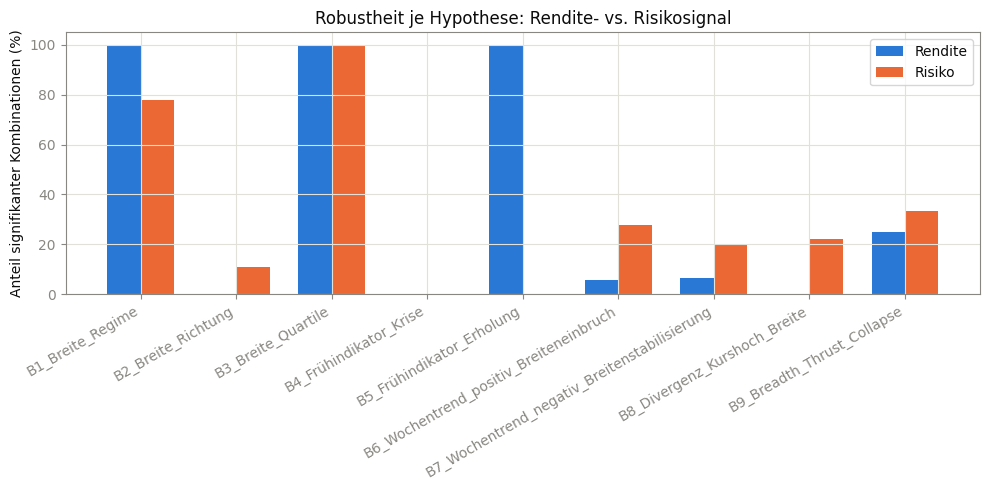

In [28]:
fig, achse = plt.subplots(figsize=(10, 5))
x = np.arange(len(pivot_robustheit))
breite = 0.35
achse.bar(x - breite / 2, pivot_robustheit["Anteil signifikant (Rendite)"] * 100, breite, label="Rendite", color=COLOR_A)
achse.bar(x + breite / 2, pivot_robustheit["Anteil signifikant (Risiko)"] * 100, breite, label="Risiko", color=COLOR_B)
achse.set_xticks(x)
achse.set_xticklabels(pivot_robustheit.index, rotation=30, ha="right")
achse.set_ylabel("Anteil signifikanter Kombinationen (%)")
achse.legend()
plt.title("Robustheit je Hypothese: Rendite- vs. Risikosignal")
plt.tight_layout()
plt.show()


**Ergebnis:** Anteil signifikanter Kombinationen (Risiko / Rendite) je
Hypothese: B1 78 %/100 %, B2 11 %/0 %, B3 100 %/100 %, B4 0 %/0 %, B5
0 %/100 %, B6 28 %/6 %, B7 20 %/7 %, B8 22 %/0 %, B9 33 %/25 %. Bei sieben
der neun Hypothesen (B2, B3, B4, B6, B7, B8 und B9) ist das Risikosignal
mindestens gleich häufig signifikant wie das Renditesignal - für die
punktuellen Ereignishypothesen (B6-B9) ist die Marktbreite damit
überwiegend ein robusteres Risiko- als Renditesignal. Zwei deutliche
Ausnahmen bilden jedoch gerade die beiden zentralen Niveau-Hypothesen: B1
(Marktbreite-Regime) ist beim Renditesignal vollständig, beim Risikosignal
nur teilweise signifikant, und B5 (Frühindikator Erholung) zeigt ein
durchgehend signifikantes Renditesignal bei einem völlig unauffälligen
Risikosignal. Das vielfach erwartete Muster "Risiko robuster als Rendite"
bestätigt sich beim Russell 2000 damit für die Ereignishypothesen, nicht
aber für die beiden wichtigsten Zustandshypothesen B1 und B5.


## 5. Einordnung und Handlungsempfehlungen


Die neun Hypothesen zeichnen für den Russell 2000 ein differenzierteres
Bild, als eine einzelne "Risiko robuster als Rendite"-Regel vermuten
ließe. Die beiden *zustandsbasierten* Hypothesen B1 (Marktbreite-Regime) und
B3 (Quartile) sind mit Abstand am robustesten - bei B3 sind alle 18
getesteten Kombinationen auf beiden Achsen signifikant, bei B1 ist sogar
das **Renditesignal** vollständig (9 von 9) und das Risikosignal nur
teilweise (7 von 9) signifikant, in beiden Fällen mit einer
Mean-Reversion-Richtung: schwächere Breite geht im Mittel mit höherer
Folgerendite einher.

Bei den *sequenziellen* Ereignishypothesen (B4-B9) zeigt sich kein
einheitliches Bild: B4 und B6 (als Krisen- bzw. Abschwächungssignale bei
positivem Trend formuliert) liefern - soweit überhaupt ein signifikanter
Effekt sichtbar wird - durchgehend die dem Warnsignal **entgegengesetzte**
Richtung (geringeres statt höheres Risiko nach dem Signal); B4 ist wegen der
mit nur 20 Ereignissen kleinen Stichprobe zudem statistisch nicht
absicherbar. B5 (Frühindikator Erholung) liefert dagegen ein durchgehend
signifikantes, deutlich positives Renditesignal ohne erkennbaren
Risikoaufschlag - ein klar positiv gerichtetes Muster. B7 und B8 zeigen
größtenteils keinen oder nur einen uneinheitlichen Effekt. B9 (Breadth
Thrust/Collapse) liefert mit dem SMA50-Breadth-Thrust das einzige Signal
dieses Notebooks, das Rendite und Risiko gleichzeitig in die günstige
Richtung verschiebt, während Breadth Collapse - anders als der Name
suggeriert - in den Russell-2000-Daten keinerlei belastbaren Effekt zeigt.

**Praxisrelevanz:** Für ein Ampelsystem eignet sich die Marktbreite auch
beim Russell 2000 vor allem als Niveau-Kennzahl (B1/B3), nicht als Trigger
für punktuelle Schwellenkreuzungen - hier variiert die Aussagekraft stark je
Parametrisierung und Fenster, und mehrere Ereignishypothesen (B4, B7 bei
den meisten Parametrisierungen, B8, B9-Collapse) sind entweder statistisch
nicht absicherbar oder ohne belastbaren Effekt. Die wiederkehrende
Mean-Reversion-Wirkung bei den Niveau-Hypothesen (schwache Breite -> im
Mittel höhere Folgerendite) deutet darauf hin, dass kurzfristige
Breitensignale eher gegenläufig als bestätigend zu interpretieren sind.


## 6. Ampel-Systematik auf Basis der Marktbreite


### 6.1 Bausteine: Breiten-Trend-Score (B1 + B2) und Drawdown-Stufe

Ein **Breiten-Trend-Score** wird aus B1 (Marktbreite-Regime) und B2
(Richtung der Marktbreite) auf dem langfristigen SMA200-Fenster gebildet
und mit einer **Drawdown-Stufe** (Abstand des Index vom bisherigen Hoch)
kombiniert. Die Kombination aus Trend- und Risikoachse soll zeigen, ob die
Marktbreite als eigenständiger Baustein einer Ampel-Systematik einen
Mehrwert liefert.


In [29]:
def trend_score(zustand_gut: pd.Series, zustand_steigend: pd.Series) -> pd.Series:
    # 0 = beide Bedingungen günstig, 2 = beide ungünstig, 1 = gemischt.
    valide = zustand_gut.notna() & zustand_steigend.notna()
    score = pd.Series(np.nan, index=df.index)
    score[valide & zustand_gut & zustand_steigend] = 0
    score[valide & (zustand_gut != zustand_steigend)] = 1
    score[valide & ~zustand_gut & ~zustand_steigend] = 2
    return score


breite_sma200_über_50 = df["breite_sma200"] > 50
breite_sma200_steigend = df["breite_sma200"].diff() > 0
df["Breiten_Trend_Score"] = trend_score(breite_sma200_über_50, breite_sma200_steigend)

# Drawdown-Stufe (Abstand vom bisherigen Hoch), direkt aus dem Indexkurs
# berechnet.
df["Allzeithoch"] = df["Close"].cummax()
df["Abstand_vom_Hoch"] = df["Close"] / df["Allzeithoch"] - 1


def drawdown_bucket(x: float) -> str:
    if x >= -0.05:
        return "Nahe am Hoch (0 bis -5%)"
    elif x >= -0.10:
        return "Leichte Korrektur (-5 bis -10%)"
    elif x >= -0.20:
        return "Korrektur (-10 bis -20%)"
    else:
        return "Bärenmarkt (< -20%)"


df["Drawdown_Bucket"] = df["Abstand_vom_Hoch"].apply(drawdown_bucket)
bucket_reihenfolge = ["Nahe am Hoch (0 bis -5%)", "Leichte Korrektur (-5 bis -10%)",
                      "Korrektur (-10 bis -20%)", "Bärenmarkt (< -20%)"]

print("Verteilung des Breiten-Trend-Score (0 = günstig, 2 = ungünstig):")
print(df["Breiten_Trend_Score"].value_counts().sort_index())


Verteilung des Breiten-Trend-Score (0 = günstig, 2 = ungünstig):
Breiten_Trend_Score
0.0000     969
1.0000    1540
2.0000     709
Name: count, dtype: int64


### 6.2 Empirische Grundlage der Kategoriengrenzen


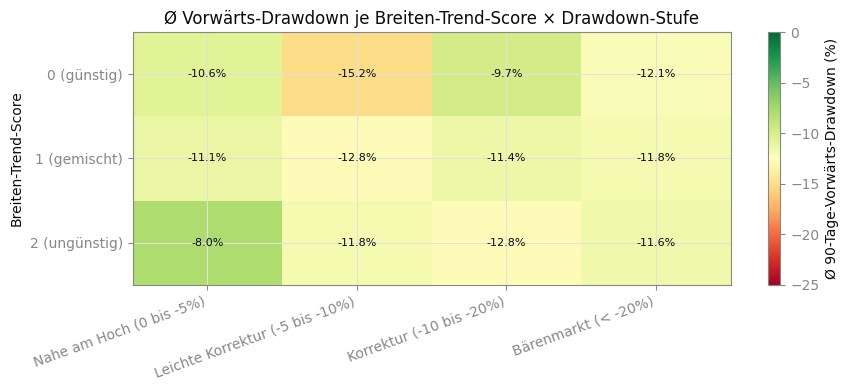

Drawdown_Bucket,Nahe am Hoch (0 bis -5%),Leichte Korrektur (-5 bis -10%),Korrektur (-10 bis -20%),Bärenmarkt (< -20%)
Breiten_Trend_Score,,,,
0.0000,-0.1059,-0.1519,-0.0975,-0.1212
1.0000,-0.1114,-0.1276,-0.1135,-0.1182
2.0000,-0.0799,-0.1183,-0.1277,-0.1155


In [30]:
heatmap_basis = df.groupby(["Breiten_Trend_Score", "Drawdown_Bucket"])["fwd_mdd_90d"].mean().unstack()
heatmap_basis = heatmap_basis[bucket_reihenfolge]

fig, achse = plt.subplots(figsize=(9, 4))
bild = achse.imshow(heatmap_basis.values * 100, cmap="RdYlGn", aspect="auto", vmin=-25, vmax=0)
achse.set_xticks(range(len(bucket_reihenfolge)))
achse.set_xticklabels(bucket_reihenfolge, rotation=20, ha="right")
achse.set_yticks(range(3))
achse.set_yticklabels(["0 (günstig)", "1 (gemischt)", "2 (ungünstig)"])
achse.set_ylabel("Breiten-Trend-Score")
for i in range(heatmap_basis.shape[0]):
    for j in range(heatmap_basis.shape[1]):
        wert = heatmap_basis.values[i, j]
        if not np.isnan(wert):
            achse.text(j, i, f"{wert * 100:.1f}%", ha="center", va="center", fontsize=8)
fig.colorbar(bild, ax=achse, label="Ø 90-Tage-Vorwärts-Drawdown (%)")
plt.title("Ø Vorwärts-Drawdown je Breiten-Trend-Score × Drawdown-Stufe")
plt.tight_layout()
plt.show()
heatmap_basis


### 6.3 Kategorienregel


In [31]:
def ampel_farbe(trend_score: float, drawdown_bucket: str) -> str:
    günstig = trend_score == 0
    ungünstig = trend_score == 2
    tief = drawdown_bucket in ("Korrektur (-10 bis -20%)", "Bärenmarkt (< -20%)")
    flach = drawdown_bucket in ("Nahe am Hoch (0 bis -5%)", "Leichte Korrektur (-5 bis -10%)")

    if günstig and flach:
        return "Grün"
    if ungünstig and tief:
        return "Rot"
    return "Gelb"


df["Ampel"] = [
    ampel_farbe(ts, db) if pd.notna(ts) else np.nan
    for ts, db in zip(df["Breiten_Trend_Score"], df["Drawdown_Bucket"])
]

print("Verteilung der Handelstage auf die drei Ampelfarben:")
print(df["Ampel"].value_counts().reindex(["Grün", "Gelb", "Rot"]))


Verteilung der Handelstage auf die drei Ampelfarben:
Ampel
Grün     843
Gelb    1813
Rot      562
Name: count, dtype: int64


### 6.4 Statistische Validierung der Ampelfarben


In [32]:
ampel_farben = ["Grün", "Gelb", "Rot"]
ampel_paare = [("Grün", "Gelb"), ("Gelb", "Rot"), ("Grün", "Rot")]

ergebnisse_ampel = []
for a, b in ampel_paare:
    maske_a = df["Ampel"] == a
    maske_b = df["Ampel"] == b
    for h in HORIZONS:
        for ziel in ["fwd_return", "fwd_mdd"]:
            res = vergleiche_gruppen(
                df.loc[maske_a, f"{ziel}_{h}d"], df.loc[maske_b, f"{ziel}_{h}d"],
                label_a=a, label_b=b,
            )
            if res:
                res.update({"vergleich": f"{a} vs. {b}", "horizont_tage": h, "zielgröße": ziel})
                ergebnisse_ampel.append(res)

tabelle_ampel = ergebnisse_zu_tabelle(ergebnisse_ampel)
tabelle_ampel[["vergleich", "horizont_tage", "zielgröße", "mean_a", "mean_b", "t_pvalue", "u_pvalue", "signifikant_5pct"]]


,vergleich,horizont_tage,zielgröße,mean_a,mean_b,t_pvalue,u_pvalue,signifikant_5pct
0,Grün vs. Gelb,30,fwd_return,0.0045,0.0119,0.0082,0.0023,True
1,Grün vs. Gelb,30,fwd_mdd,-0.0570,-0.0634,0.0012,0.0000,True
2,Grün vs. Gelb,60,fwd_return,0.0100,0.0208,0.0066,0.0025,True
3,Grün vs. Gelb,60,fwd_mdd,-0.0873,-0.0941,0.0155,0.0000,True
4,Grün vs. Gelb,90,fwd_return,0.0089,0.0326,0.0000,0.0000,True
5,Grün vs. Gelb,90,fwd_mdd,-0.1157,-0.1150,0.8427,0.0015,False
6,Gelb vs. Rot,30,fwd_return,0.0119,0.0228,0.0042,0.0017,True
7,Gelb vs. Rot,30,fwd_mdd,-0.0634,-0.0771,0.0000,0.0000,True
8,Gelb vs. Rot,60,fwd_return,0.0208,0.0488,0.0000,0.0000,True
9,Gelb vs. Rot,60,fwd_mdd,-0.0941,-0.1058,0.0000,0.0000,True


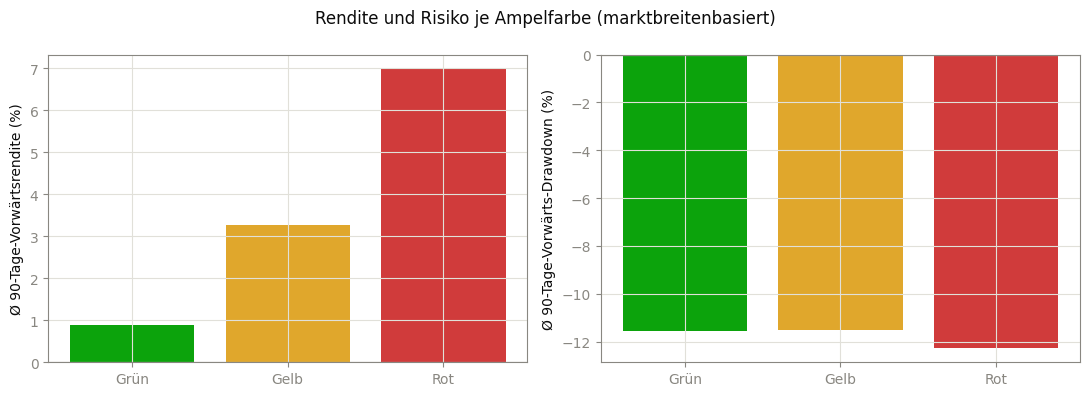

In [33]:
mittelwerte_ampel = df.groupby("Ampel")[["fwd_return_90d", "fwd_mdd_90d"]].mean().reindex(ampel_farben)
ampel_farbcodes = {"Grün": COLOR_GOOD, "Gelb": COLOR_WARN, "Rot": COLOR_BAD}

fig, achsen = plt.subplots(1, 2, figsize=(11, 4))
for achse, spalte, titel in zip(achsen, ["fwd_return_90d", "fwd_mdd_90d"],
                                 ["Ø 90-Tage-Vorwärtsrendite", "Ø 90-Tage-Vorwärts-Drawdown"]):
    achse.bar(mittelwerte_ampel.index, mittelwerte_ampel[spalte] * 100,
              color=[ampel_farbcodes[f] for f in mittelwerte_ampel.index])
    achse.axhline(0, color=COLOR_MUTED, linewidth=0.8)
    achse.set_ylabel(f"{titel} (%)")
fig.suptitle("Rendite und Risiko je Ampelfarbe (marktbreitenbasiert)")
fig.tight_layout()
plt.show()


**Ergebnis:** Verteilung der Handelstage: Grün 843 (26,2 %), Gelb 1.813
(56,3 %), Rot 562 (17,5 %). Das Risiko trennt die drei Farben überwiegend
in der erwarteten Richtung (Grün am sichersten, Rot am riskantesten): Bei
30 und 60 Tagen sind alle drei Farbpaare signifikant und monoton (mittlerer
60-Tage-Drawdown: Grün -8,7 %, Gelb -9,4 %, Rot -10,6 %); bei 90 Tagen
nähern sich Grün (-11,6 %) und Gelb (-11,5 %) jedoch praktisch an
(nicht signifikant), nur der Abstand zu Rot (-12,3 %) bleibt bestehen. Die
**Rendite** ist dagegen in allen neun Farbpaar-Horizont-Kombinationen
signifikant - allerdings in einer dem Ampel-Gedanken **entgegengesetzten**
Richtung: Die mittlere Vorwärtsrendite steigt durchgehend von Grün über
Gelb zu Rot an (90 Tage: Grün 0,9 %, Gelb 3,3 %, Rot 7,0 %). Die
marktbreitenbasierte Ampel trennt das Risiko damit größtenteils in der
gewünschten Richtung, liefert bei der Rendite jedoch ein klares
Mean-Reversion-Signal: Die "rote" Phase mit dem höchsten Risiko geht im
Mittel mit der höchsten, nicht der niedrigsten Folgerendite einher.


### 6.5 Ampel-Hintergrund im Kursverlauf


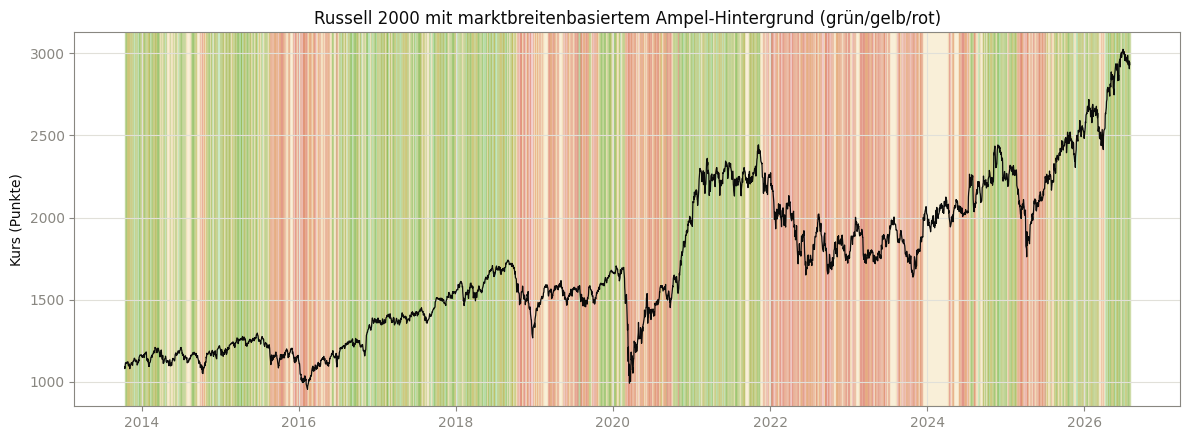

In [34]:
fig, achse = plt.subplots(figsize=(12, 4.5))
for farbe in ampel_farben:
    maske = df["Ampel"] == farbe
    achse.fill_between(df.index, 0, 1, where=maske, color=ampel_farbcodes[farbe], alpha=0.18,
                        transform=achse.get_xaxis_transform())
achse.plot(df.index, df["Close"], color=COLOR_PRICE, linewidth=0.9)
achse.set_ylabel("Kurs (Punkte)")
achse.set_title(f"{INDEX_NAME} mit marktbreitenbasiertem Ampel-Hintergrund (grün/gelb/rot)")
fig.tight_layout()
plt.show()


## 7. Was-wäre-wenn-Analyse: Wirkung des Risikophasen-Ausschlusses

Für jede Hypothese, bei der sich ein **anhaltender** Regimezustand
definieren lässt (im Unterschied zu den punktuellen Ereignishypothesen
B4-B9), wird simuliert, wie sich Gesamtrendite, annualisierte Rendite (CAGR)
und maximaler Drawdown verändert hätten, wenn an Tagen mit dem jeweils
ungünstigeren Regimezustand nicht investiert gewesen wäre.

**Methodische Abgrenzung:** Es wird ausschließlich der zum jeweiligen
Zeitpunkt bereits bekannte Regimezustand verwendet (kein Rückschaufehler).
Transaktionskosten und eine Verzinsung der Cash-Position an ausgeschlossenen
Tagen werden nicht berücksichtigt.

**B4, B5, B6, B7, B8 und B9 werden bewusst ausgeschlossen:** Es handelt sich
um seltene Punktereignisse bzw. Divergenzsignale ohne anhaltenden
Regimezustand - daraus lässt sich keine Phase ableiten, die über einen
längeren Zeitraum "ausgeschlossen" werden könnte. Einbezogen werden B1
(Marktbreite-Regime), B2 (Richtung der Marktbreite), B3 (unteres Quartil als
Risikostufe) sowie die kombinierte Ampel aus Abschnitt 6.


### 7.1 Backtest-Hilfsfunktionen


In [35]:
def historischer_max_drawdown(werte: pd.Series) -> float:
    laufendes_hoch = werte.cummax()
    return (werte / laufendes_hoch - 1).min()


def was_wäre_wenn(schlecht: pd.Series, label: str) -> dict:
    tagesrendite = df["Close"].pct_change().fillna(0)
    schlecht_bereinigt = schlecht.reindex(df.index).fillna(False)

    strategie_rendite = tagesrendite.where(~schlecht_bereinigt, 0)
    equity_buy_hold = (1 + tagesrendite).cumprod()
    equity_strategie = (1 + strategie_rendite).cumprod()

    jahre = (df.index[-1] - df.index[0]).days / 365.25

    def kennzahlen(equity: pd.Series) -> tuple[float, float, float]:
        gesamtrendite = equity.iloc[-1] - 1
        cagr = equity.iloc[-1] ** (1 / jahre) - 1
        mdd = historischer_max_drawdown(equity)
        return gesamtrendite, cagr, mdd

    gr_bh, cagr_bh, mdd_bh = kennzahlen(equity_buy_hold)
    gr_st, cagr_st, mdd_st = kennzahlen(equity_strategie)

    return {
        "hypothese": label,
        "anteil_schlecht_tage": schlecht_bereinigt.mean(),
        "gesamtrendite_buy_hold": gr_bh, "cagr_buy_hold": cagr_bh, "max_drawdown_buy_hold": mdd_bh,
        "gesamtrendite_strategie": gr_st, "cagr_strategie": cagr_st, "max_drawdown_strategie": mdd_st,
        "equity_buy_hold": equity_buy_hold, "equity_strategie": equity_strategie,
    }


print("Backtest-Hilfsfunktionen definiert.")


Backtest-Hilfsfunktionen definiert.


### 7.2 Regime-Definitionen je Hypothese


In [36]:
regime_definitionen: dict[str, pd.Series] = {}

for w in BREADTH_WINDOWS:
    über, _ = breite_regime(w)
    regime_definitionen[f"B1_SMA{w}"] = ~über.reindex(df.index).fillna(False)

for w in BREADTH_WINDOWS:
    steigend, _ = breite_richtung(w)
    regime_definitionen[f"B2_SMA{w}"] = ~steigend.reindex(df.index).fillna(False)

for w in BREADTH_WINDOWS:
    regime_definitionen[f"B3_SMA{w}_Q1"] = df[f"Quartil_SMA{w}"] == QUARTIL_LABELS[0]

regime_definitionen["Ampel_Rot"] = df["Ampel"] == "Rot"

# Um einen Rückschaufehler zu vermeiden, darf am Handelstag T nur der am
# Schlusskurs von T-1 bereits bekannte Regimezustand über die Teilnahme an
# Tag T entscheiden - nicht der auf Basis von T selbst berechnete Zustand.
regime_definitionen = {
    name: serie.reindex(df.index).fillna(False).shift(1).fillna(False).astype(bool)
    for name, serie in regime_definitionen.items()
}

print("Regime-Definitionen für die Was-wäre-wenn-Analyse:", list(regime_definitionen.keys()))


Regime-Definitionen für die Was-wäre-wenn-Analyse: ['B1_SMA20', 'B1_SMA50', 'B1_SMA200', 'B2_SMA20', 'B2_SMA50', 'B2_SMA200', 'B3_SMA20_Q1', 'B3_SMA50_Q1', 'B3_SMA200_Q1', 'Ampel_Rot']


### 7.3 Konsolidierte Kennzahlenübersicht


In [37]:
ergebnisse_www = [was_wäre_wenn(schlecht, name) for name, schlecht in regime_definitionen.items()]
tabelle_was_wäre_wenn = pd.DataFrame(ergebnisse_www).drop(columns=["equity_buy_hold", "equity_strategie"])
tabelle_was_wäre_wenn


,hypothese,anteil_schlecht_tage,gesamtrendite_buy_hold,cagr_buy_hold,max_drawdown_buy_hold,gesamtrendite_strategie,cagr_strategie,max_drawdown_strategie
0,B1_SMA20,0.4764,1.6886,0.0804,-0.4306,0.4237,0.0280,-0.3016
1,B1_SMA50,0.4562,1.6886,0.0804,-0.4306,-0.1481,-0.0125,-0.4189
2,B1_SMA200,0.4291,1.6886,0.0804,-0.4306,0.2751,0.0192,-0.2308
3,B2_SMA20,0.5034,1.6886,0.0804,-0.4306,-0.3627,-0.0346,-0.4961
4,B2_SMA50,0.5019,1.6886,0.0804,-0.4306,-0.3778,-0.0364,-0.4954
5,B2_SMA200,0.4897,1.6886,0.0804,-0.4306,-0.2777,-0.0251,-0.3716
6,B3_SMA20_Q1,0.1252,1.6886,0.0804,-0.4306,0.7754,0.0459,-0.3747
7,B3_SMA50_Q1,0.1075,1.6886,0.0804,-0.4306,1.6156,0.0780,-0.4241
8,B3_SMA200_Q1,0.0684,1.6886,0.0804,-0.4306,1.2616,0.0659,-0.3940
9,Ampel_Rot,0.1746,1.6886,0.0804,-0.4306,0.2346,0.0166,-0.4457


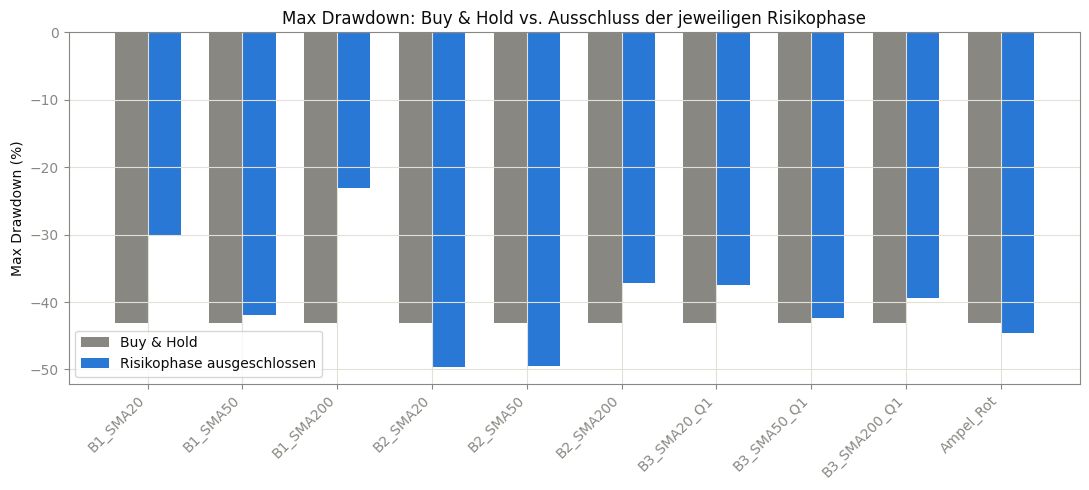

In [38]:
fig, achse = plt.subplots(figsize=(11, 5))
x = np.arange(len(tabelle_was_wäre_wenn))
breite = 0.35
achse.bar(x - breite / 2, tabelle_was_wäre_wenn["max_drawdown_buy_hold"] * 100, breite,
          label="Buy & Hold", color=COLOR_MUTED)
achse.bar(x + breite / 2, tabelle_was_wäre_wenn["max_drawdown_strategie"] * 100, breite,
          label="Risikophase ausgeschlossen", color=COLOR_A)
achse.set_xticks(x)
achse.set_xticklabels(tabelle_was_wäre_wenn["hypothese"], rotation=45, ha="right")
achse.set_ylabel("Max Drawdown (%)")
achse.legend()
plt.title("Max Drawdown: Buy & Hold vs. Ausschluss der jeweiligen Risikophase")
plt.tight_layout()
plt.show()


**Ergebnis:** Buy & Hold erzielt im auswertbaren Zeitraum seit 2013 (ab dem
Beginn der Marktbreite-Historie am 2013-10-14) eine Gesamtrendite von
168,9 % (CAGR 8,0 %) bei einem Max Drawdown von -43,1 %. Der Ausschluss
der jeweils „schlechten“ Marktbreite-Regime senkt den Max Drawdown nicht
in allen zehn Parametrisierungen: Am stärksten wirkt B1/SMA200 (42,9 %
ausgeschlossene Tage), das den Max Drawdown auf -23,1 % senkt, allerdings
bei einer deutlich geringeren CAGR von 1,9 % (gegenüber 8,0 % bei Buy &
Hold). B1/SMA20 (Max Drawdown -30,2 %, CAGR 2,8 %) zeigt ein ähnliches
Bild. B3/SMA50_Q1 (10,75 % ausgeschlossene Tage) hält die CAGR mit 7,8 %
nahe am Buy-&-Hold-Niveau, senkt den Max Drawdown aber nur geringfügig auf
-42,4 %. Bei B2 (Richtung der Marktbreite) und der kombinierten Ampel
verschlechtert sich der Max Drawdown teils sogar gegenüber Buy & Hold
(B2/SMA20: -49,6 %; Ampel: -44,6 % gegenüber -43,1 %), bei gleichzeitig
deutlich negativer bzw. stark reduzierter CAGR.


### 7.4 Vertiefte Einzelbetrachtung

Für die kombinierte Ampel (Rot-Phasen) wird zusätzlich der zeitliche
Verlauf dargestellt: oben der Kursverlauf mit rot hinterlegter
Ausschlussphase, darunter die Wertentwicklung von Buy & Hold gegenüber der
Ausschluss-Strategie (logarithmische Skala, Startwert = 1).


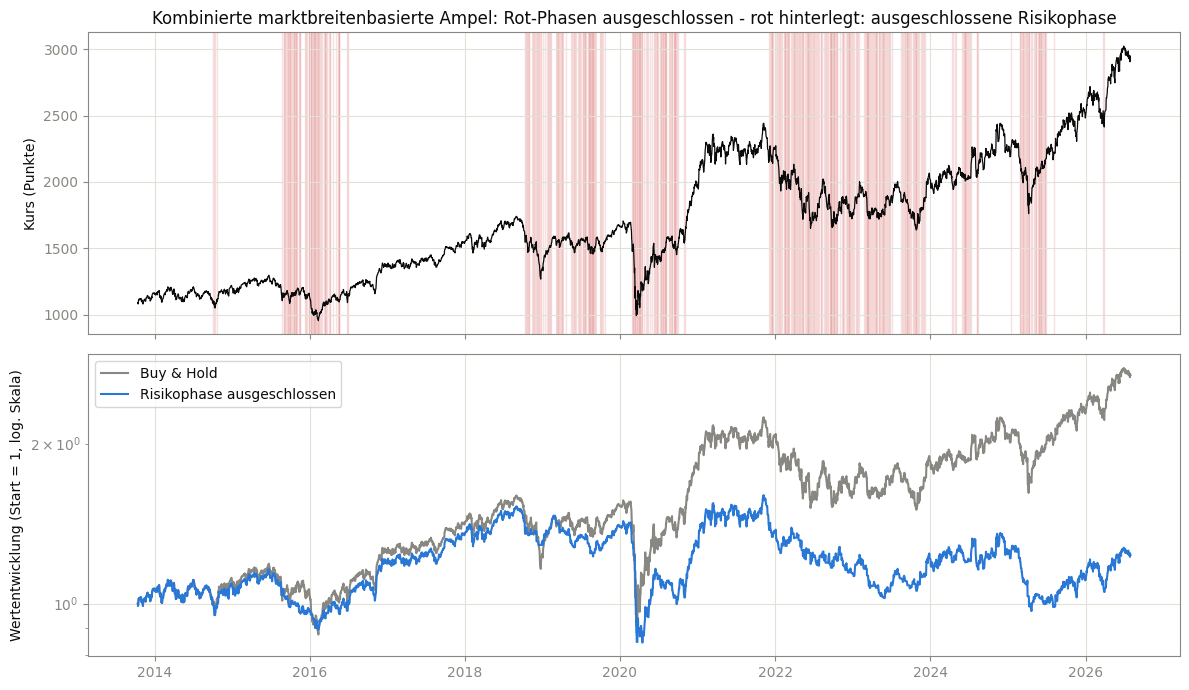

Anteil ausgeschlossener Handelstage: 17.5%
Gesamtrendite  - Buy & Hold: 168.9% | Ausschluss: 23.5%
CAGR           - Buy & Hold: 8.0% | Ausschluss: 1.7%
Max Drawdown   - Buy & Hold: -43.1% | Ausschluss: -44.6%


In [39]:
def plotte_was_wäre_wenn(name: str, schlecht: pd.Series, titel: str) -> dict:
    ergebnis = was_wäre_wenn(schlecht, name)
    schlecht_reindiziert = schlecht.reindex(df.index).fillna(False)

    fig, (achse_kurs, achse_equity) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

    achse_kurs.fill_between(df.index, 0, 1, where=schlecht_reindiziert, color=COLOR_BAD, alpha=0.15,
                             transform=achse_kurs.get_xaxis_transform())
    achse_kurs.plot(df.index, df["Close"], color=COLOR_PRICE, linewidth=0.9)
    achse_kurs.set_ylabel("Kurs (Punkte)")
    achse_kurs.set_title(f"{titel} - rot hinterlegt: ausgeschlossene Risikophase")

    achse_equity.plot(df.index, ergebnis["equity_buy_hold"], color=COLOR_MUTED, label="Buy & Hold")
    achse_equity.plot(df.index, ergebnis["equity_strategie"], color=COLOR_A, label="Risikophase ausgeschlossen")
    achse_equity.set_yscale("log")
    achse_equity.set_ylabel("Wertentwicklung (Start = 1, log. Skala)")
    achse_equity.legend()

    fig.tight_layout()
    plt.show()

    print(f"Anteil ausgeschlossener Handelstage: {ergebnis['anteil_schlecht_tage']:.1%}")
    print(f"Gesamtrendite  - Buy & Hold: {ergebnis['gesamtrendite_buy_hold']:.1%} | Ausschluss: {ergebnis['gesamtrendite_strategie']:.1%}")
    print(f"CAGR           - Buy & Hold: {ergebnis['cagr_buy_hold']:.1%} | Ausschluss: {ergebnis['cagr_strategie']:.1%}")
    print(f"Max Drawdown   - Buy & Hold: {ergebnis['max_drawdown_buy_hold']:.1%} | Ausschluss: {ergebnis['max_drawdown_strategie']:.1%}")
    return ergebnis


_ = plotte_was_wäre_wenn("Ampel_Rot", regime_definitionen["Ampel_Rot"], "Kombinierte marktbreitenbasierte Ampel: Rot-Phasen ausgeschlossen")


**Ergebnis:** Der Ausschluss der 17,5 % Rot-Handelstage verschlechtert den
Max Drawdown geringfügig (-43,1 % bei Buy & Hold gegenüber -44,6 % bei
Ausschluss) und senkt die annualisierte Rendite deutlich (8,0 % gegenüber
1,7 %). Wie beim NASDAQ 100 liefert die kombinierte Ampel damit auch beim
Russell 2000 keinen erkennbaren Risikoreduktions-Vorteil. Der Kursverlauf
zeigt, dass die Rot-Phasen erwartungsgemäß mit den großen Krisenphasen im
auswertbaren Zeitraum seit 2013 zusammenfallen (u. a. Ende 2018, Frühjahr
2020, 2022); die Finanzkrise 2008/2009 liegt vor dem Beginn der
Marktbreite-Historie und ist in dieser Betrachtung entsprechend nicht
enthalten.


## 8. Export der Ergebnisse


In [40]:
INDEX_DATEINAME = INDEX_NAME.replace(" ", "_").replace("&", "and")

xlsx_pfad = EXPORT_DIR / f"{INDEX_DATEINAME}_Marktbreite_hypothesenanalysen.xlsx"
with pd.ExcelWriter(xlsx_pfad, engine="openpyxl") as writer:
    for name, tabelle in alle_ergebnisse.items():
        if tabelle is not None and len(tabelle) > 0:
            tabelle.to_excel(writer, sheet_name=name[:31], index=False)
    tabelle_robustheit.to_excel(writer, sheet_name="Robustheit_Übersicht", index=False)
    tabelle_ampel.to_excel(writer, sheet_name="Ampel_Validierung", index=False)
    tabelle_was_wäre_wenn.to_excel(writer, sheet_name="Was_wäre_wenn", index=False)

csv_dateien = []
for name, tabelle in alle_ergebnisse.items():
    if tabelle is None or len(tabelle) == 0:
        continue
    csv_pfad = EXPORT_DIR / f"{INDEX_DATEINAME}_{name}.csv"
    tabelle.to_csv(csv_pfad, index=False)
    csv_dateien.append(csv_pfad.name)

robustheit_csv = EXPORT_DIR / f"{INDEX_DATEINAME}_Robustheit_Übersicht.csv"
tabelle_robustheit.to_csv(robustheit_csv, index=False)
csv_dateien.append(robustheit_csv.name)

ampel_csv = EXPORT_DIR / f"{INDEX_DATEINAME}_Ampel_Validierung.csv"
tabelle_ampel.to_csv(ampel_csv, index=False)
csv_dateien.append(ampel_csv.name)

was_wäre_wenn_csv = EXPORT_DIR / f"{INDEX_DATEINAME}_Was_wäre_wenn.csv"
tabelle_was_wäre_wenn.to_csv(was_wäre_wenn_csv, index=False)
csv_dateien.append(was_wäre_wenn_csv.name)

print(f"Excel-Arbeitsmappe gespeichert: {xlsx_pfad}")
print("Einzel-CSV-Dateien gespeichert:")
for f in csv_dateien:
    print(" -", f)


Excel-Arbeitsmappe gespeichert: Hypothesenanalysen\Russell_2000_Marktbreite_hypothesenanalysen.xlsx
Einzel-CSV-Dateien gespeichert:
 - Russell_2000_B1_Breite_Regime.csv
 - Russell_2000_B2_Breite_Richtung.csv
 - Russell_2000_B3_Breite_Quartile.csv
 - Russell_2000_B4_Frühindikator_Krise.csv
 - Russell_2000_B5_Frühindikator_Erholung.csv
 - Russell_2000_B6_Wochentrend_positiv_Breiteneinbruch.csv
 - Russell_2000_B7_Wochentrend_negativ_Breitenstabilisierung.csv
 - Russell_2000_B8_Divergenz_Kurshoch_Breite.csv
 - Russell_2000_B9_Breadth_Thrust_Collapse.csv
 - Russell_2000_Robustheit_Übersicht.csv
 - Russell_2000_Ampel_Validierung.csv
 - Russell_2000_Was_wäre_wenn.csv


## 9. Zusammenfassung


Dieses Notebook untersucht, ob die Marktbreite des Russell 2000 (Anteil der
Indexmitglieder über ihrem eigenen SMA20/50/200) eine eigenständige,
statistisch prüfbare Aussagekraft für die Rendite- und Risikoentwicklung
des Gesamtindex besitzt. Datengrundlage sind tägliche TradingView-
Breitendaten, die erst ab 2013-10-14 vorliegen (die Finanzkrise 2008/2009
ist damit nicht abgedeckt), sowie bereits bereinigte Kurs- und SMA-Daten
des Index seit 2007. Der tatsächlich ausgewertete Zeitraum beginnt durch
den inneren Verbund beider Quellen einheitlich 2013-10-14 und reicht bis
2026-07-31.

**Kernbefunde:**

- Das *Niveau* der Marktbreite liefert die robustesten Signale, jedoch mit
  einer im Vergleich zur intuitiven Erwartung überraschenden Gewichtung:
  Bei B1 (Regime > 50 %/< 50 %) ist das **Renditesignal** vollständig
  (9/9), das Risikosignal nur teilweise (7/9) signifikant; bei B3
  (Quartile) sind beide Achsen vollständig signifikant (18/18 KW-Omnibus-
  sowie 18/18 Q1-vs-Q4-Vergleiche). Beide Hypothesen zeigen eine
  Mean-Reversion-Richtung: schwächere Breite geht im Mittel mit höherer
  Folgerendite einher.
- Die *Richtung* der Marktbreite (B2) liefert dagegen kaum eigenständige
  Information (1 von 18 signifikant).
- Die sequenziellen Ereignishypothesen (B4-B8) zeigen ein uneinheitliches
  Bild: B4 und B6 (Warnsignale bei positivem Trend) gehen - soweit
  überhaupt signifikant - mit **geringerem**, nicht höherem Risiko einher;
  B5 liefert ein durchgehend signifikantes, deutlich **positives**
  Renditesignal ohne erkennbaren Risikoaufschlag; B7 zeigt nur in einer
  Minderheit der Parametrisierungen ein signifikant **höheres** Risiko
  statt einer "ruhigen Erholung"; B8 zeigt keine einheitliche Richtung.
  B4 ist wegen nur 20 historischen Ereignissen (Marktbreite-Historie seit
  2013) statistisch nicht robust absicherbar; bei B7 (SMA200, "steigt über
  50 %") und B9 (SMA200, beide Muster) reicht die Ereigniszahl (3 bzw. 3
  und 1) ebenfalls nicht für einen Signifikanztest und wird rein deskriptiv
  ausgewiesen.
- B9 (Breadth Thrust/Collapse) liefert mit dem SMA50-Breadth-Thrust (131
  Ereignisse) das einzige Signal des Notebooks mit robustem, **günstigem**
  Effekt auf beiden Achsen gleichzeitig: höhere Rendite **und** niedrigeres
  Risiko. Breadth Collapse zeigt dagegen bei SMA20/SMA50 keinen
  signifikanten Effekt.
- Die marktbreitenbasierte Ampel (Kapitel 6) trennt das Risiko überwiegend
  in der erwarteten Richtung (Grün am sichersten), bei 90 Tagen nähern sich
  Grün und Gelb jedoch an; bei der Rendite zeigt sich durchgehend (9/9
  signifikant) das Gegenteil der Ampel-Logik: Rot geht mit der höchsten,
  nicht der niedrigsten Folgerendite einher (90 Tage: Grün 0,9 %, Gelb
  3,3 %, Rot 7,0 %). Der Ausschluss der Rot-Phasen (17,5 % der
  Handelstage) verschlechtert dagegen sowohl den seit 2013 beobachtbaren
  Max Drawdown (-43,1 % auf -44,6 %) als auch die CAGR (8,0 % auf 1,7 %) -
  wie beim NASDAQ 100 liefert die Ampel auch beim Russell 2000 keinen
  erkennbaren Nutzen (Kapitel 7).

**Übergreifende Einordnung:** Das vielfach erwartete Muster "Risiko
robuster als Rendite" bestätigt sich beim Russell 2000 für die meisten
Ereignishypothesen (B6-B9), nicht jedoch für die beiden zentralen
Zustandshypothesen B1 und B5, bei denen umgekehrt die Rendite das robustere
Signal ist. Für punktuelle Schwellenkreuzungen (B4-B8) zeigt sich zudem
überwiegend eine Mean-Reversion-Tendenz statt einer Bestätigung der
jeweils formulierten Warnhypothese - mit B5 und dem SMA50-Breadth-Thrust
(B9) als zwei Ausnahmen, die ein eigenständiges, positiv gerichtetes
Signal liefern. Wegen der erst 2013 einsetzenden Marktbreite-Historie sind
mehrere Ereignishypothesen (B4 vollständig, einzelne Parametrisierungen bei
B7 und B9) nur mit kleiner oder unzureichender Stichprobe bzw. rein
deskriptiv auswertbar.
